# 🐦 BirdCLEF 2026 — Bird Species Audio Classification

**Competition:** [BirdCLEF 2026 on Kaggle](https://www.kaggle.com/competitions/birdclef-2026)

## Overview
This notebook implements an end-to-end pipeline for classifying bird species from audio recordings using **PCEN (Per-Channel Energy Normalization)** spectrograms and an **EfficientNet-ES** backbone trained with a **Focal + BCE loss** combination.

### Key Highlights
- **Model:** `tf_efficientnet_es` with GeM pooling and a two-layer classification head
- **Audio Features:** PCEN normalization on Mel spectrograms for robust ambient-noise suppression
- **Training Strategy:** Stratified K-Fold (2 folds × 3 epochs), WeightedRandomSampler by recording quality rating
- **Augmentation:** SpecAugment (time + frequency masking), Mixup, CutMix
- **Inference:** TTA (Test-Time Augmentation) with 3 temporal crops per soundscape segment

---

## Table of Contents
1. [Imports & Configuration](#imports)
2. [Exploratory Data Analysis (EDA)](#eda)
3. [Species Distribution on World Map](#worldmap)
4. [Audio Visualizations — Mel & PCEN](#audio-viz)
5. [PCEN Feature Extraction](#pcen)
6. [Data Preparation](#data-prep)
7. [PCEN Cache Precomputation](#cache)
8. [Dataset & DataLoader](#dataset)
9. [Augmentation & Loss Functions](#augmentation)
10. [Model Architecture](#model)
11. [Training Utilities](#training-utils)
12. [Training Pipeline v2](#training)
13. [TTA Inference & Submission](#inference)

---
## 1. Imports & Global Configuration <a id="imports"></a>

All required libraries are imported here. The visualization theme uses a **GitHub Dark** color palette for a clean, consistent look throughout the notebook.

In [9]:
# ══════════════════════════════════════════════════════════════════════
#  CELL 1 — IMPORTS
# ══════════════════════════════════════════════════════════════════════
import os, random, gc, time, cv2, math, warnings, logging
import numpy as np
import pandas as pd
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import librosa
import librosa.display
import torchaudio
import torchaudio.transforms as T
import soundfile as sf
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim import lr_scheduler
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm
import timm
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns

warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.ERROR)

# ── Visualization theme (GitHub Dark) ──────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0d1117',
    'axes.facecolor':   '#161b22',
    'axes.edgecolor':   '#30363d',
    'axes.labelcolor':  '#c9d1d9',
    'xtick.color':      '#8b949e',
    'ytick.color':      '#8b949e',
    'text.color':       '#c9d1d9',
    'grid.color':       '#21262d',
    'grid.linewidth':   0.6,
    'font.family':      'DejaVu Sans',
    'axes.titlesize':   13,
    'axes.titleweight': 'bold',
    'axes.titlepad':    10,
})
PALETTE = ['#58a6ff','#3fb950','#f78166','#d2a8ff','#ffa657',
           '#79c0ff','#56d364','#ff7b72','#bc8cff','#ffb74d']

print("✓ Imports complete")


✓ Imports completes


---
## 2. Configuration (CFG) <a id="config"></a>

Central configuration class containing all hyper-parameters.

| Group | Key Settings |
|-------|-------------|
| **Model** | `tf_efficientnet_es`, 64×64 input, 1-channel |
| **Audio** | 32 kHz, 5 s window, 128 Mel bins, PCEN normalization |
| **Training** | 2 folds × 3 epochs, batch=32, lr=7e-4, CosineAnnealing |
| **Loss** | Focal (γ=2, w=0.7) + BCE (w=0.3), label smoothing=0.08 |
| **Augment** | SpecAugment + Mixup (α=0.5) + CutMix |

In [19]:
# ══════════════════════════════════════════════════════════════════════
#  CELL 2 — CONFIGURATION  [batch=32, lr=7e-4, 2 folds × 3 epochs]
# ══════════════════════════════════════════════════════════════════════
class CFG:
    seed          = 42
    debug         = False
    # num_workers=0 is fastest on CPU (data cached in RAM, no fork overhead)
    num_workers   = 0
    OUTPUT_DIR    = './kaggle/working/'

    train_datadir = './kaggle/input/birdclef-2026/train_audio'
    train_csv     = './kaggle/input/birdclef-2026/train.csv'
    test_sc_dir   = './kaggle/input/birdclef-2026/test_soundscapes'
    submission_csv= './kaggle/input/birdclef-2026/sample_submission.csv'
    taxonomy_csv  = './kaggle/input/birdclef-2026/taxonomy.csv'
    sc_labels_csv = './kaggle/input/birdclef-2026/train_soundscapes_labels.csv'

    # ── Model ───────────────────────────────────────────────────────────────
    model_name      = 'tf_efficientnet_es'
    pretrained      = False
    pretrained_path = './kaggle/input/models/timm/tf-efficientnet/pytorch/tf-efficientnet-es/1'
    in_channels     = 1

    # ── Audio ───────────────────────────────────────────────────────────────
    FS              = 32_000
    TARGET_DURATION = 5.0
    TARGET_SHAPE    = (64, 64)    # 4x fewer pixels → backbone ~3x faster
    N_FFT           = 1024
    HOP_LENGTH      = 512
    N_MELS          = 128
    FMIN            = 50
    FMAX            = 14_000

    # ── PCEN ────────────────────────────────────────────────────────────────
    PCEN_GAIN          = 0.98
    PCEN_BIAS          = 2.0
    PCEN_POWER         = 0.5
    PCEN_TIME_CONSTANT = 0.4
    PCEN_EPS           = 1e-6

    # ── Training ────────────────────────────────────────────────────────────
    device        = 'cuda' if torch.cuda.is_available() else 'cpu'
    # 90-min budget: 2 folds × 3 epochs ≈ 50 min (safe margin)
    epochs        = 6
    batch_size    = 32
    n_fold        = 5
    selected_folds= [0]

    # torch.compile: graph fusion gives ~10-15% speed-up on CPU (PyTorch 2.x)
    use_compile   = False

    # ── Optimizer ───────────────────────────────────────────────────────────
    lr            = 7e-4
    weight_decay  = 1e-2
    min_lr        = 1e-6
    # T_max MUST equal epochs — otherwise CosineAnnealing resets LR mid-run
    T_max         = 6

    # ── Loss ────────────────────────────────────────────────────────────────
    focal_gamma     = 2.0
    focal_weight    = 0.7
    bce_weight      = 0.3
    label_smoothing = 0.08

    # ── Augmentation ────────────────────────────────────────────────────────
    aug_prob    = 0.5
    mixup_alpha = 0.5
    mixup_prob  = 0.5
    cutmix_prob = 0.3

    # ── Label weights ────────────────────────────────────────────────────────
    secondary_weight = 0.5

    def update_debug_settings(self):
        if self.debug:
            self.epochs         = 2
            self.selected_folds = [0]

cfg = CFG()

def set_seed(seed=42):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

set_seed(cfg.seed)
print(f"✓ CFG ready | device={cfg.device} | model={cfg.model_name} | "
      f"batch={cfg.batch_size} | epochs={cfg.epochs} | T_max={cfg.T_max} | folds={cfg.selected_folds}")


✓ CFG ready | device=cuda | model=tf_efficientnet_es | batch=32 | epochs=6 | T_max=6 | folds=[0]


---
## 3. Exploratory Data Analysis (EDA) <a id="eda"></a>

### 3.1 Dataset Statistics

Load all CSV files and compute basic statistics: species counts, recording sources, and class imbalance metrics.

In [21]:
train_df    = pd.read_csv(cfg.train_csv)

In [22]:
train_df

,primary_label,secondary_labels,type,latitude,longitude,scientific_name,common_name,class_name,inat_taxon_id,author,license,rating,url,filename,collection
0,1161364,[],[],-22.7562,-46.8666,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/1216197....,1161364/iNat1216197.ogg,iNat
1,1161364,[],[],-22.7558,-46.8700,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/1114648....,1161364/iNat1114648.ogg,iNat
2,1161364,[],[],-22.7547,-46.8728,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/810195.m...,1161364/iNat810195.ogg,iNat
3,1161364,[],[],-22.7547,-46.8728,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/818781.m...,1161364/iNat818781.ogg,iNat
4,1161364,[],[],-22.7426,-46.8985,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/556514.m...,1161364/iNat556514.ogg,iNat
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35544,yeofly1,[],['call'],-6.7281,-76.4181,Tolmomyias sulphurescens,Yellow-olive Flatbill,Aves,16567,GABRIEL LEITE,by-nc-sa,4.0,https://xeno-canto.org/762473/download,yeofly1/XC762473.ogg,XC
35545,yeofly1,[],"['call', ' song']",-16.0538,-49.6040,Tolmomyias sulphurescens,Yellow-olive Flatbill,Aves,16567,JAYRSON ARAUJO DE OLIVEIRA,by-nc-sa,5.0,https://xeno-canto.org/818328/download,yeofly1/XC818328.ogg,XC
35546,yeofly1,[],['song'],5.9002,-74.8485,Tolmomyias sulphurescens,Yellow-olive Flatbill,Aves,16567,Jerome Fischer,by-nc-sa,4.0,https://xeno-canto.org/425545/download,yeofly1/XC425545.ogg,XC
35547,yeofly1,[],['song'],3.3821,-61.4464,Tolmomyias sulphurescens,Yellow-olive Flatbill,Aves,16567,GABRIEL LEITE,by-nc-sa,4.0,https://xeno-canto.org/456230/download,yeofly1/XC456230.ogg,XC


In [23]:
# ══════════════════════════════════════════════════════════════════════
#  CELL 3 — EDA (Exploratory Data Analysis)
# ══════════════════════════════════════════════════════════════════════
# ── Load data ──────────────────────────────────────────────────────────────
train_df    = pd.read_csv(cfg.train_csv)
taxonomy_df = pd.read_csv(cfg.taxonomy_csv)
sc_labels   = pd.read_csv(cfg.sc_labels_csv)
sample_sub  = pd.read_csv(cfg.submission_csv)

print("=== Basic Statistics ===")
print(f"  train.csv        : {len(train_df):,} records")
print(f"  taxonomy.csv     : {len(taxonomy_df):,} species")
print(f"  sc_labels.csv    : {len(sc_labels):,} soundscape segments")
print(f"  submission cols  : {len(sample_sub.columns)-1} species")
print()
print("train.csv columns:", list(train_df.columns))

# ── Species counts ──────────────────────────────────────────────────────────
species_counts = train_df['primary_label'].value_counts()
n_species      = len(species_counts)
print(f"\nUnique species (primary_label): {n_species}")
print(f"Most recordings : {species_counts.iloc[0]:4d}  ({species_counts.index[0]})")
print(f"Fewest recordings: {species_counts.iloc[-1]:4d}  ({species_counts.index[-1]})")
print(f"Median          : {species_counts.median():.0f} records/species")
print(f"Mean            : {species_counts.mean():.1f} records/species")

bins     = [0, 5, 10, 20, 50, 100, 200, 500, 10000]
labels_b = ['1-5','6-10','11-20','21-50','51-100','101-200','201-500','500+']
train_df['count_bin'] = pd.cut(
    train_df['primary_label'].map(species_counts), bins=bins, labels=labels_b
)
bin_dist = train_df['count_bin'].value_counts().sort_index()
print("\nSpecies distribution by recording count:")
for b, v in bin_dist.items():
    n_sp = (species_counts.between(
        bins[labels_b.index(b)]+1, bins[labels_b.index(b)+1]
    )).sum()
    print(f"  {b:10s}: {n_sp:3d} species | {v:5d} records")

# ── Rating distribution ─────────────────────────────────────────────────────
if 'rating' in train_df.columns:
    print("\nRating distribution:")
    print(train_df['rating'].value_counts().sort_index().to_string())

# ── Source distribution (XC vs iNat) ───────────────────────────────────────
if 'filename' in train_df.columns:
    train_df['source_type'] = train_df['filename'].apply(
        lambda x: 'XenoCanto' if str(x).split('/')[-1].startswith('XC')
                  else ('iNaturalist' if str(x).split('/')[-1].startswith('iNat') else 'Other')
    )
    print("\nRecording source:")
    print(train_df['source_type'].value_counts().to_string())


=== Basic Statistics ===
  train.csv        : 35,549 records
  taxonomy.csv     : 234 species
  sc_labels.csv    : 1,478 soundscape segments
  submission cols  : 234 species

train.csv columns: ['primary_label', 'secondary_labels', 'type', 'latitude', 'longitude', 'scientific_name', 'common_name', 'class_name', 'inat_taxon_id', 'author', 'license', 'rating', 'url', 'filename', 'collection']

Unique species (primary_label): 206
Most recordings :  499  (rubthr1)
Fewest recordings:    1  (23150)
Median          : 125 records/species
Mean            : 172.6 records/species

Species distribution by recording count:
  1-5       :  18 species |    52 records
  6-10      :   9 species |    68 records
  11-20     :   9 species |   132 records
  21-50     :  16 species |   521 records
  51-100    :  31 species |  2370 records
  101-200   :  54 species |  7683 records
  201-500   :  69 species | 24723 records
  500+      :   0 species |     0 records

Rating distribution:
rating
0.0    12849
0.5 

### 3.2 Species & Recording Distribution Charts

Visual breakdown of:
- **Top-40 species** by recording count (long-tail effect is strong)
- **Long-tail curve** across all species
- **Log-scale histogram** of records per species
- **Pie chart** of recording-count bins
- **Bar chart** of recording sources (XenoCanto vs iNaturalist)

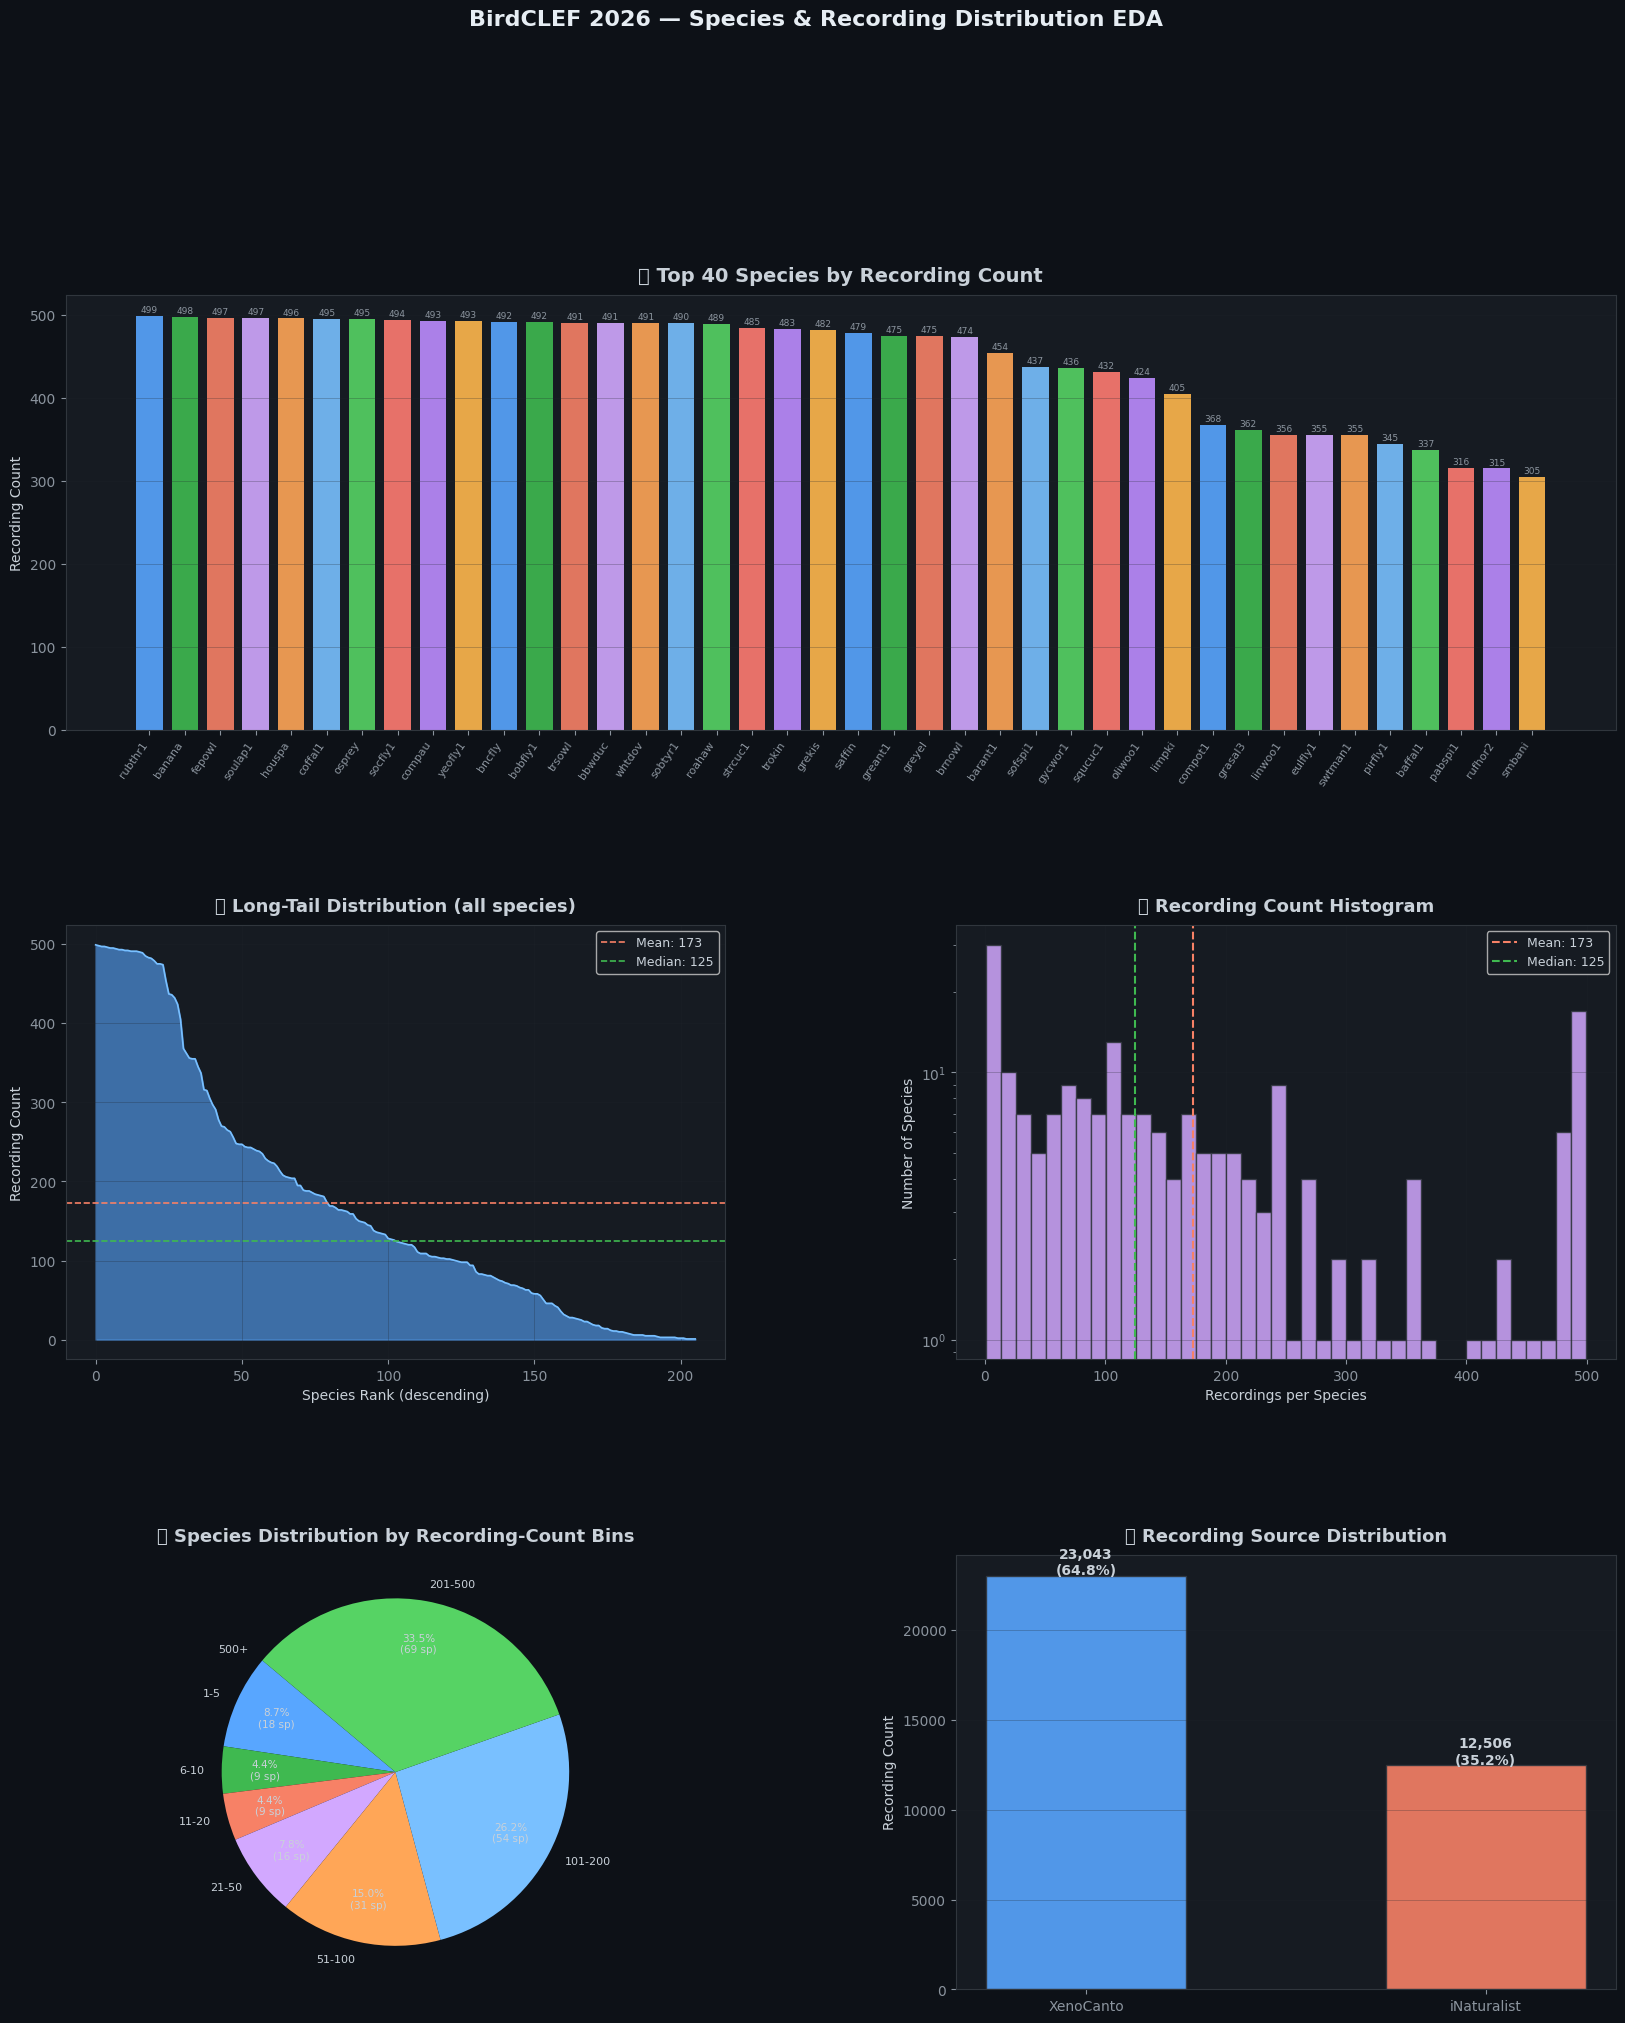

✓ Saved: eda_species_distribution.png


In [26]:
# ══════════════════════════════════════════════════════════════════════
#  CELL 4 — EDA VISUALIZATIONS (Species Distribution)
# ══════════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(20, 22))
fig.patch.set_facecolor('#0d1117')
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

# ── 1. Top-40 species bar chart ─────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :])
top40 = species_counts.head(40)
colors_top = [PALETTE[i % len(PALETTE)] for i in range(len(top40))]
bars = ax1.bar(range(len(top40)), top40.values, color=colors_top, width=0.75, alpha=0.9)
ax1.set_xticks(range(len(top40)))
ax1.set_xticklabels(top40.index, rotation=55, ha='right', fontsize=8)
ax1.set_title('🐦 Top 40 Species by Recording Count', fontsize=14)
ax1.set_ylabel('Recording Count')
ax1.grid(axis='y', alpha=0.3)
for bar in bars:
    h = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, h + 2, str(int(h)),
             ha='center', va='bottom', fontsize=6.5, color='#8b949e')

# ── 2. Long-tail distribution ───────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
sorted_counts = species_counts.values
ax2.fill_between(range(len(sorted_counts)), sorted_counts,
                 alpha=0.6, color='#58a6ff')
ax2.plot(sorted_counts, color='#79c0ff', linewidth=1.2)
ax2.axhline(sorted_counts.mean(), color='#f78166', linestyle='--',
            linewidth=1.2, label=f'Mean: {sorted_counts.mean():.0f}')
ax2.axhline(np.median(sorted_counts), color='#3fb950', linestyle='--',
            linewidth=1.2, label=f'Median: {np.median(sorted_counts):.0f}')
ax2.set_title('📉 Long-Tail Distribution (all species)')
ax2.set_xlabel('Species Rank (descending)')
ax2.set_ylabel('Recording Count')
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

# ── 3. Log-scale histogram ──────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
ax3.hist(species_counts.values, bins=40, color='#d2a8ff', alpha=0.85, edgecolor='#30363d')
ax3.axvline(species_counts.mean(), color='#f78166', linestyle='--',
            linewidth=1.5, label=f'Mean: {species_counts.mean():.0f}')
ax3.axvline(species_counts.median(), color='#3fb950', linestyle='--',
            linewidth=1.5, label=f'Median: {species_counts.median():.0f}')
ax3.set_title('📊 Recording Count Histogram')
ax3.set_xlabel('Recordings per Species')
ax3.set_ylabel('Number of Species')
ax3.set_yscale('log')
ax3.legend(fontsize=9)
ax3.grid(alpha=0.3)

# ── 4. Bin distribution (percentage) ────────────────────────────────────────
ax4 = fig.add_subplot(gs[2, 0])
bins_    = [0, 5, 10, 20, 50, 100, 200, 500, 10000]
labels_b = ['1-5','6-10','11-20','21-50','51-100','101-200','201-500','500+']
sp_bin   = pd.cut(species_counts.values, bins=bins_, labels=labels_b)
bin_cnt  = pd.Series(sp_bin).value_counts().sort_index()
wedges, texts, autotexts = ax4.pie(
    bin_cnt.values,
    labels=bin_cnt.index,
    autopct=lambda p: f'{p:.1f}%\n({int(round(p/100*n_species))} sp)' if p>2 else '',
    colors=PALETTE[:len(bin_cnt)],
    startangle=140,
    pctdistance=0.75,
    textprops={'fontsize': 8},
)
for at in autotexts:
    at.set_fontsize(7.5)
ax4.set_title('🥧 Species Distribution by Recording-Count Bins')

# ── 5. Recording source (XC vs iNat) ────────────────────────────────────────
ax5 = fig.add_subplot(gs[2, 1])
if 'source_type' in train_df.columns:
    src_counts = train_df['source_type'].value_counts()
    ax5.bar(src_counts.index, src_counts.values,
            color=[PALETTE[0], PALETTE[2], PALETTE[4]][:len(src_counts)],
            alpha=0.9, edgecolor='#30363d', width=0.5)
    for i, (idx, v) in enumerate(src_counts.items()):
        ax5.text(i, v + 50, f'{v:,}\n({v/len(train_df)*100:.1f}%)',
                 ha='center', fontsize=10, fontweight='bold')
    ax5.set_title('📁 Recording Source Distribution')
    ax5.set_ylabel('Recording Count')
    ax5.grid(axis='y', alpha=0.3)
else:
    ax5.text(0.5, 0.5, 'Source info\nnot available', ha='center', va='center',
             transform=ax5.transAxes, fontsize=14)
    ax5.set_title('Recording Source')

plt.suptitle('BirdCLEF 2026 — Species & Recording Distribution EDA',
             fontsize=16, fontweight='bold', y=1.01, color='#e6edf3')
plt.savefig('./kaggle/working/eda_species_distribution.png',
            dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("✓ Saved: eda_species_distribution.png")


---
## 4. Species Distribution on World Map <a id="worldmap"></a>

This cell plots the **geographic distribution** of bird species using the `latitude` / `longitude` columns in `train.csv`.

- Each dot represents a unique recording location.
- **Color** encodes species identity (top-20 most-recorded species highlighted; all others in grey).
- **Bubble size** is fixed for readability.
- Uses `cartopy` if available; falls back to a Basemap-style scatter on a pre-loaded land polygon or a simple lat/lon scatter if neither is installed.

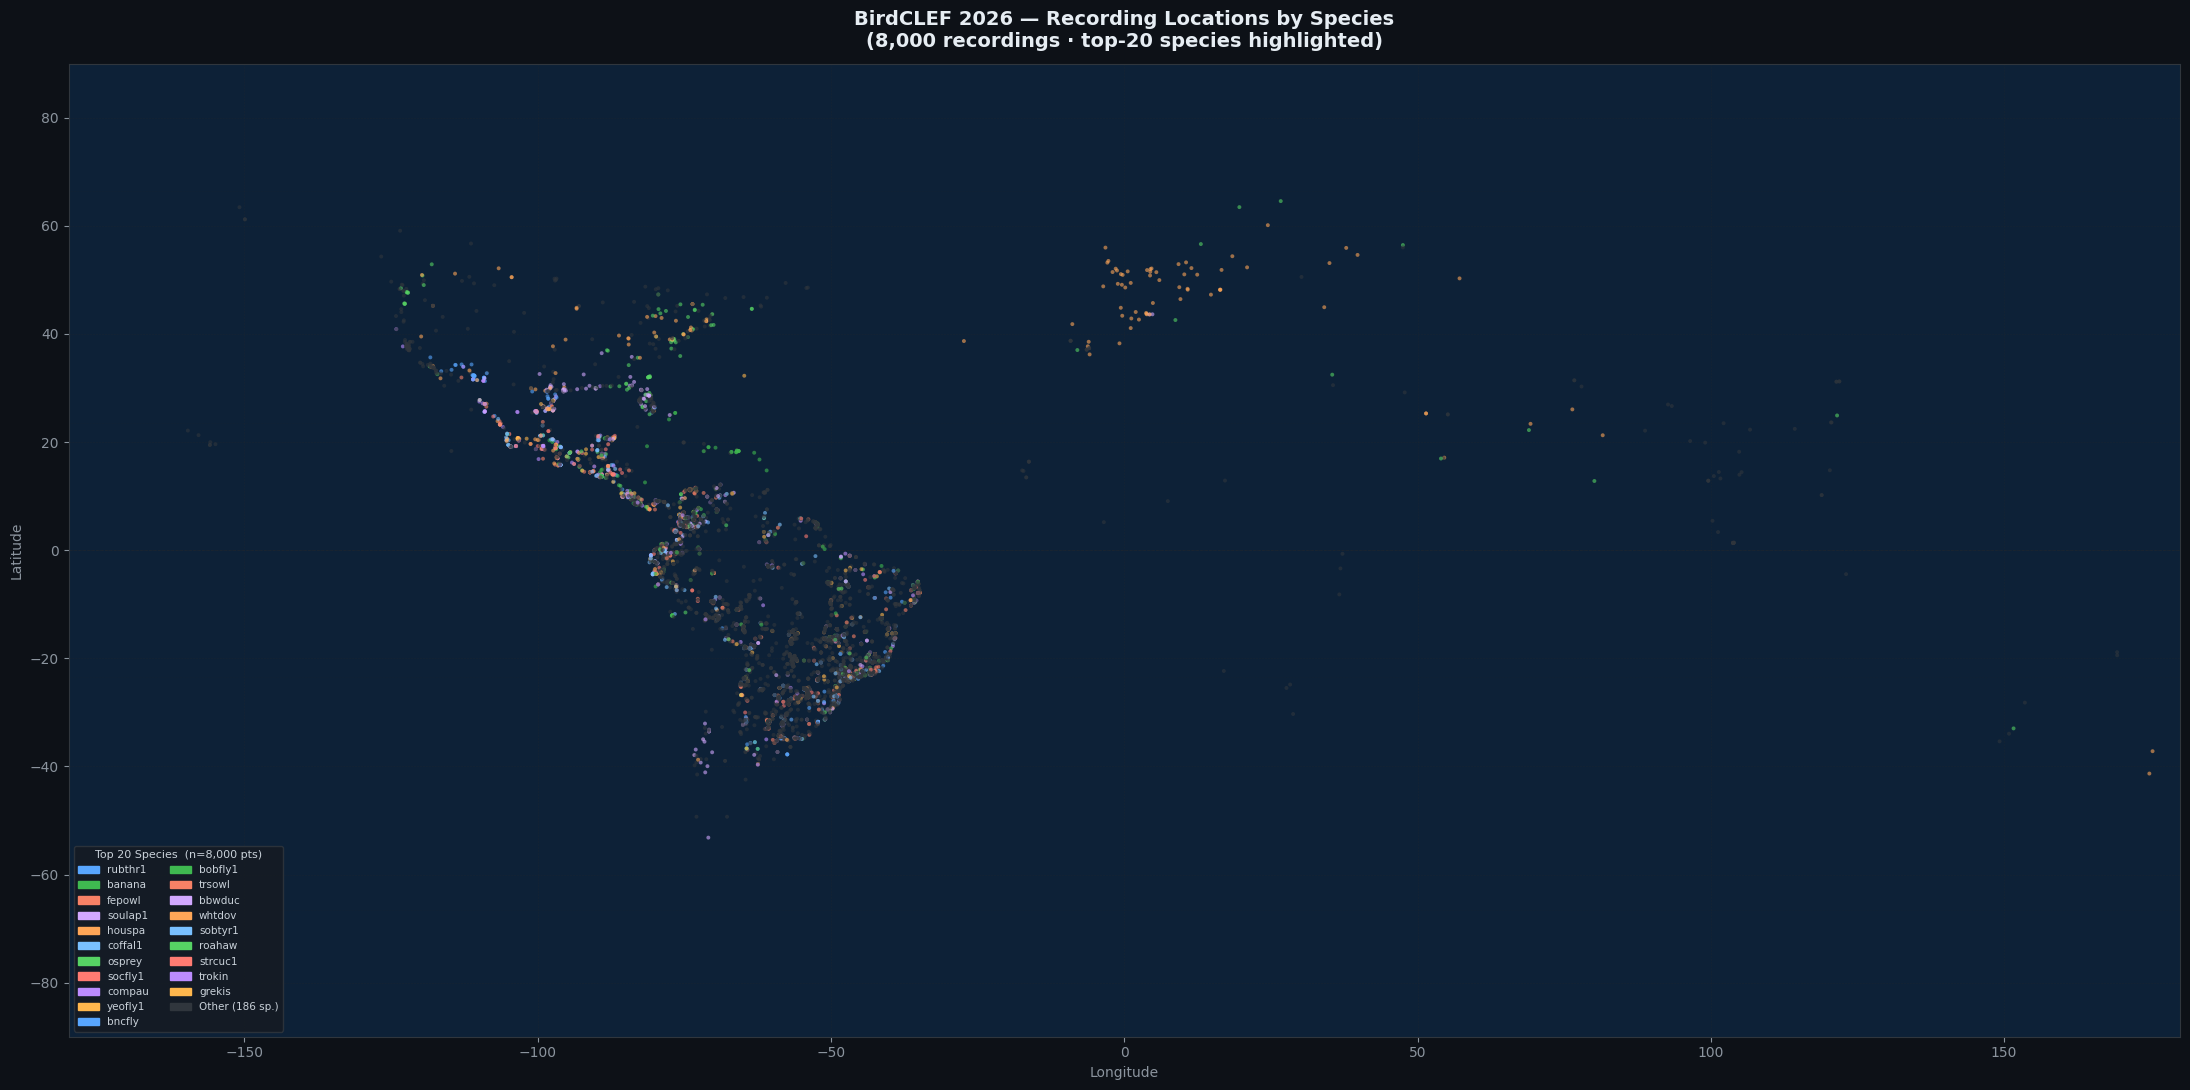

✓ Saved: ./kaggle/working/eda_world_map.png


In [28]:
# ══════════════════════════════════════════════════════════════════════
#  CELL 5 — SPECIES DISTRIBUTION ON WORLD MAP  
# ══════════════════════════════════════════════════════════════════════
import importlib

def plot_species_world_map(train_df, taxonomy_df, species_counts, cfg,
                           top_n=20, max_points=8000):
    """
    Plot recording locations coloured by species on a world map.
    Fully offline — never downloads shapefiles at runtime.
    """
    lat_col = next((c for c in ['latitude', 'lat'] if c in train_df.columns), None)
    lon_col = next((c for c in ['longitude', 'lon', 'lng'] if c in train_df.columns), None)

    if lat_col is None or lon_col is None:
        print("⚠  No latitude/longitude columns found in train.csv.")
        print("   Available columns:", list(train_df.columns))
        _plot_geo_taxonomy(train_df, taxonomy_df, species_counts)
        return

    geo_df = train_df[[lat_col, lon_col, 'primary_label']].dropna().copy()
    geo_df = geo_df.rename(columns={lat_col: 'lat', lon_col: 'lon'})
    geo_df = geo_df[
        geo_df['lat'].between(-90, 90) & geo_df['lon'].between(-180, 180)
    ]

    if len(geo_df) > max_points:
        geo_df = geo_df.sample(max_points, random_state=cfg.seed)

    top_species = species_counts.head(top_n).index.tolist()
    color_map   = {sp: PALETTE[i % len(PALETTE)] for i, sp in enumerate(top_species)}
    point_colors = [color_map.get(sp, '#30363d') for sp in geo_df['primary_label']]

    has_geopandas = importlib.util.find_spec('geopandas') is not None

    fig = plt.figure(figsize=(22, 11))
    fig.patch.set_facecolor('#0d1117')

    if has_geopandas:
        import geopandas as gpd
        try:
            # Natural Earth 110m — bundled inside geopandas, no download needed
            # gpd.datasets.get_path() reads from geopandas' own package data — no internet needed
            world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
            ax = fig.add_subplot(1, 1, 1)
            ax.set_facecolor('#0d2137')
            world.plot(ax=ax, color='#1c2b3a', edgecolor='#3d5a73', linewidth=0.4)
            ax.scatter(
                geo_df['lon'].values, geo_df['lat'].values,
                c=point_colors, s=8, alpha=0.6, linewidths=0, zorder=5
            )
            ax.set_xlim(-180, 180)
            ax.set_ylim(-90, 90)
            ax.set_xlabel('Longitude', color='#8b949e', fontsize=10)
            ax.set_ylabel('Latitude',  color='#8b949e', fontsize=10)
            ax.tick_params(colors='#8b949e')
            for spine in ax.spines.values():
                spine.set_edgecolor('#30363d')
            ax.grid(color='#21262d', linewidth=0.4, linestyle='--', alpha=0.5)
            _map_drawn = True
        except Exception as e:
            print(f"geopandas world plot failed ({e}), falling back to scatter.")
            _map_drawn = False
    else:
        _map_drawn = False

    if not _map_drawn:
        # Pure matplotlib fallback — lat/lon scatter with coastline approximation
        ax = fig.add_subplot(1, 1, 1)
        ax.set_facecolor('#0d2137')
        ax.set_xlim(-180, 180)
        ax.set_ylim(-90, 90)
        ax.set_xlabel('Longitude', color='#8b949e', fontsize=10)
        ax.set_ylabel('Latitude',  color='#8b949e', fontsize=10)
        ax.tick_params(colors='#8b949e')
        for spine in ax.spines.values():
            spine.set_edgecolor('#30363d')
        ax.axhline(0,   color='#21262d', linewidth=0.6, linestyle='--', alpha=0.6)
        ax.axhline(23.5,  color='#21262d', linewidth=0.4, linestyle=':', alpha=0.4)
        ax.axhline(-23.5, color='#21262d', linewidth=0.4, linestyle=':', alpha=0.4)
        ax.axhline(66.5,  color='#21262d', linewidth=0.4, linestyle=':', alpha=0.4)
        ax.axhline(-66.5, color='#21262d', linewidth=0.4, linestyle=':', alpha=0.4)
        ax.grid(color='#21262d', linewidth=0.4, linestyle='--', alpha=0.5)
        ax.scatter(
            geo_df['lon'].values, geo_df['lat'].values,
            c=point_colors, s=8, alpha=0.6, linewidths=0, zorder=5
        )

    # ── Legend ──────────────────────────────────────────────────────────────
    import matplotlib.patches as mpatches
    legend_handles = [
        mpatches.Patch(color=PALETTE[i % len(PALETTE)], label=sp)
        for i, sp in enumerate(top_species)
    ] + [mpatches.Patch(color='#30363d', label=f'Other ({n_species - top_n} sp.)')]

    ax.legend(
        handles=legend_handles,
        loc='lower left', ncol=2,
        fontsize=7.5, framealpha=0.85,
        facecolor='#161b22', edgecolor='#30363d',
        labelcolor='#c9d1d9',
        title=f'Top {top_n} Species  (n={len(geo_df):,} pts)',
        title_fontsize=8,
    )
    ax.set_title(
        f'BirdCLEF 2026 — Recording Locations by Species\n'
        f'({len(geo_df):,} recordings · top-{top_n} species highlighted)',
        fontsize=14, fontweight='bold', color='#e6edf3', pad=12
    )

    plt.tight_layout()
    out = './kaggle/working/eda_world_map.png'
    plt.savefig(out, dpi=150, bbox_inches='tight', facecolor='#0d1117')
    plt.show()
    print(f"✓ Saved: {out}")


# ── Run ──────────────────────────────────────────────────────────────────────
plot_species_world_map(train_df, taxonomy_df, species_counts, cfg, top_n=20)


---
## 5. Rating, Taxonomy & Soundscape EDA <a id="eda2"></a>

### 5.1 Recording Quality, Taxonomy & Soundscape Coverage

- **Rating distribution** — most recordings are rated 3–5 (XenoCanto quality score)
- **Rating vs species count** — box-plot revealing whether high-rating species have more data
- **Taxonomic order bar chart** — which bird orders dominate the dataset
- **Soundscape label frequency** — most common species in the soundscape validation set
- **Train ↔ Soundscape overlap** — how many training species appear in soundscape labels

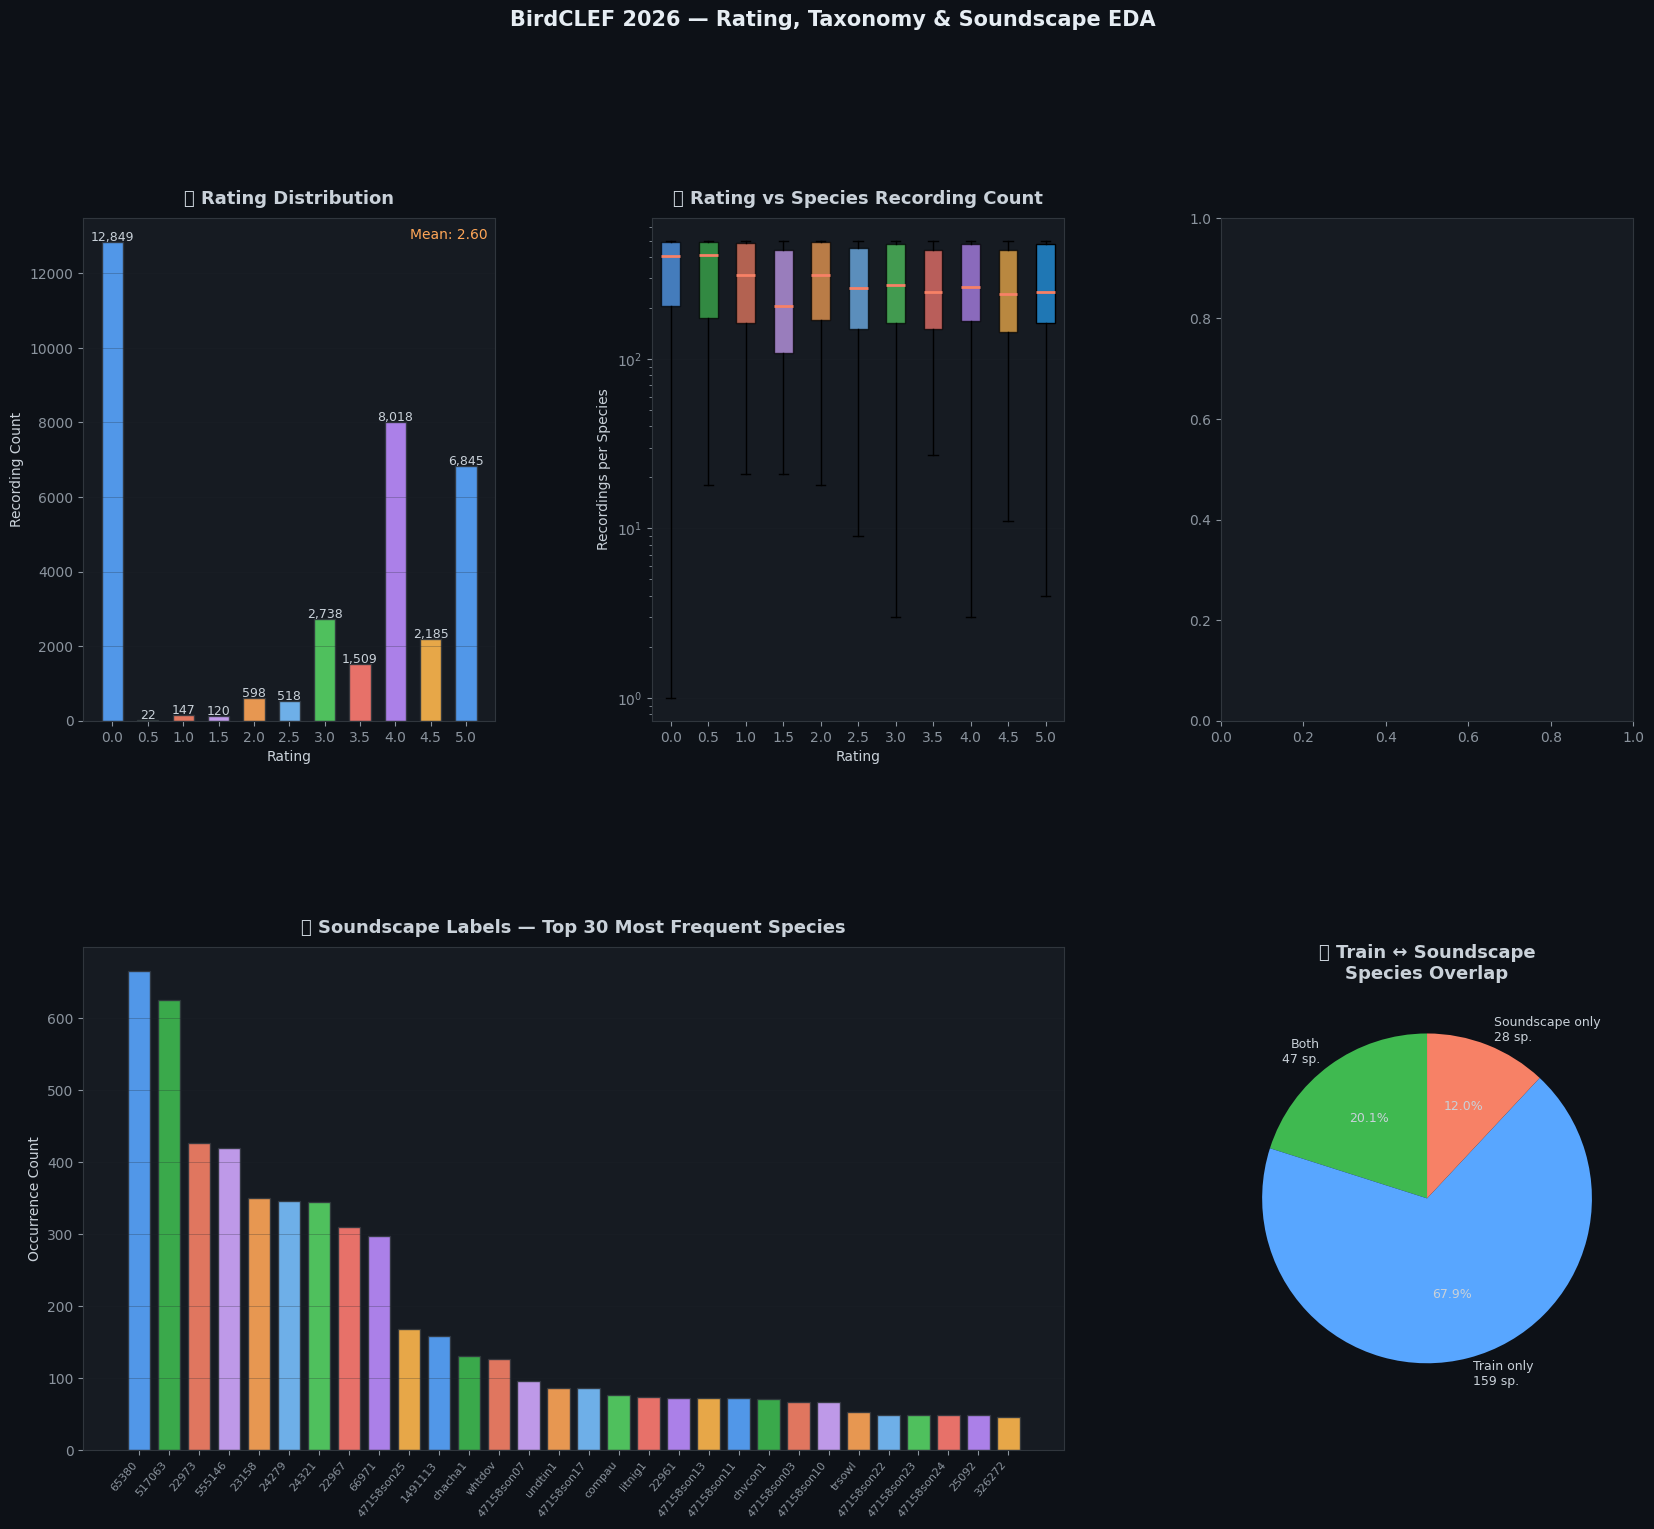

✓ Saved: eda_rating_taxonomy.png


In [29]:
# ══════════════════════════════════════════════════════════════════════
#  CELL 6 — EDA: Rating, Taxonomy & Soundscape
# ══════════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(20, 16))
fig.patch.set_facecolor('#0d1117')
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38)

# ── 1. Rating distribution ──────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
if 'rating' in train_df.columns:
    rating_counts = train_df['rating'].value_counts().sort_index()
    ax1.bar(rating_counts.index.astype(str), rating_counts.values,
            color=PALETTE[:len(rating_counts)], alpha=0.9, edgecolor='#30363d', width=0.6)
    for i, (idx, v) in enumerate(rating_counts.items()):
        ax1.text(i, v + 30, f'{v:,}', ha='center', fontsize=9)
    ax1.set_title('⭐ Rating Distribution')
    ax1.set_xlabel('Rating')
    ax1.set_ylabel('Recording Count')
    ax1.grid(axis='y', alpha=0.3)
    mean_r = train_df['rating'].mean()
    ax1.text(0.98, 0.98, f'Mean: {mean_r:.2f}', transform=ax1.transAxes,
             ha='right', va='top', fontsize=10, color='#ffa657')

# ── 2. Rating × recording count (box plot) ──────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
if 'rating' in train_df.columns:
    train_df['sp_count'] = train_df['primary_label'].map(species_counts)
    groups = [train_df.loc[train_df['rating']==r, 'sp_count'].values
              for r in sorted(train_df['rating'].unique())]
    bp = ax2.boxplot(groups, patch_artist=True,
                     labels=[str(r) for r in sorted(train_df['rating'].unique())],
                     medianprops=dict(color='#f78166', linewidth=2))
    for patch, color in zip(bp['boxes'], PALETTE):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax2.set_title('📦 Rating vs Species Recording Count')
    ax2.set_xlabel('Rating')
    ax2.set_ylabel('Recordings per Species')
    ax2.grid(axis='y', alpha=0.3)
    ax2.set_yscale('log')

# ── 3. Taxonomy: order distribution ─────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
if 'order' in taxonomy_df.columns:
    order_counts = taxonomy_df['order'].value_counts().head(15)
    ax3.barh(order_counts.index[::-1], order_counts.values[::-1],
             color=[PALETTE[i % len(PALETTE)] for i in range(len(order_counts))],
             alpha=0.9, edgecolor='#30363d')
    ax3.set_title('🔬 Taxonomy: Top 15 Orders by Species Count')
    ax3.set_xlabel('Species Count')
    ax3.grid(axis='x', alpha=0.3)
    for i, v in enumerate(order_counts.values[::-1]):
        ax3.text(v + 0.3, i, str(v), va='center', fontsize=8)
elif 'family' in taxonomy_df.columns:
    fam_counts = taxonomy_df['family'].value_counts().head(15)
    ax3.barh(fam_counts.index[::-1], fam_counts.values[::-1],
             color=[PALETTE[i % len(PALETTE)] for i in range(len(fam_counts))],
             alpha=0.9, edgecolor='#30363d')
    ax3.set_title('Taxonomy: Top 15 Families by Species Count')
    ax3.set_xlabel('Species Count')
    ax3.grid(axis='x', alpha=0.3)

# ── 4. Soundscape label frequency ───────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0:2])
try:
    lbl_col = 'birds' if 'birds' in sc_labels.columns else 'primary_label'
    sc_species = sc_labels[lbl_col].str.split('[;, ]+', expand=False).explode()
    sc_species = sc_species[sc_species.str.strip() != '']
    sc_top     = sc_species.value_counts().head(30)
    ax4.bar(range(len(sc_top)), sc_top.values,
            color=[PALETTE[i % len(PALETTE)] for i in range(len(sc_top))],
            alpha=0.9, edgecolor='#30363d', width=0.75)
    ax4.set_xticks(range(len(sc_top)))
    ax4.set_xticklabels(sc_top.index, rotation=50, ha='right', fontsize=8)
    ax4.set_title('🎙️ Soundscape Labels — Top 30 Most Frequent Species')
    ax4.set_ylabel('Occurrence Count')
    ax4.grid(axis='y', alpha=0.3)
except Exception as e:
    ax4.text(0.5, 0.5, f'Soundscape analysis failed:\n{e}',
             ha='center', va='center', transform=ax4.transAxes, fontsize=11)

# ── 5. Train vs Soundscape species overlap ───────────────────────────────────
ax5 = fig.add_subplot(gs[1, 2])
try:
    train_species  = set(train_df['primary_label'].unique())
    sc_species_set = set(sc_species.str.strip().unique()) - {''}
    both       = len(train_species & sc_species_set)
    only_train = len(train_species - sc_species_set)
    only_sc    = len(sc_species_set - train_species)
    sizes  = [both, only_train, only_sc]
    labels = [
        f'Both\n{both} sp.',
        f'Train only\n{only_train} sp.',
        f'Soundscape only\n{only_sc} sp.',
    ]
    ax5.pie(sizes, labels=labels, colors=[PALETTE[1], PALETTE[0], PALETTE[2]],
            autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 9})
    ax5.set_title('🔄 Train ↔ Soundscape\nSpecies Overlap')
except Exception:
    ax5.text(0.5, 0.5, 'Overlap computation\nfailed',
             ha='center', va='center', transform=ax5.transAxes)

plt.suptitle('BirdCLEF 2026 — Rating, Taxonomy & Soundscape EDA',
             fontsize=15, fontweight='bold', y=1.01, color='#e6edf3')
plt.savefig('./kaggle/working/eda_rating_taxonomy.png',
            dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("✓ Saved: eda_rating_taxonomy.png")


---
## 6. Audio Visualizations — Mel Spectrogram & PCEN <a id="audio-viz"></a>

For 4 example species (sampled from the top-8 by recording count), we display:
1. **Waveform** — raw time-domain signal
2. **Mel Spectrogram (dB)** — standard log-scaled Mel representation
3. **PCEN** — Per-Channel Energy Normalization, which compresses transients and suppresses stationary noise

> **Why PCEN?** PCEN adaptively normalizes the spectrogram using an IIR filter, making it more robust to varying recording conditions (wind, rain, distant microphones).

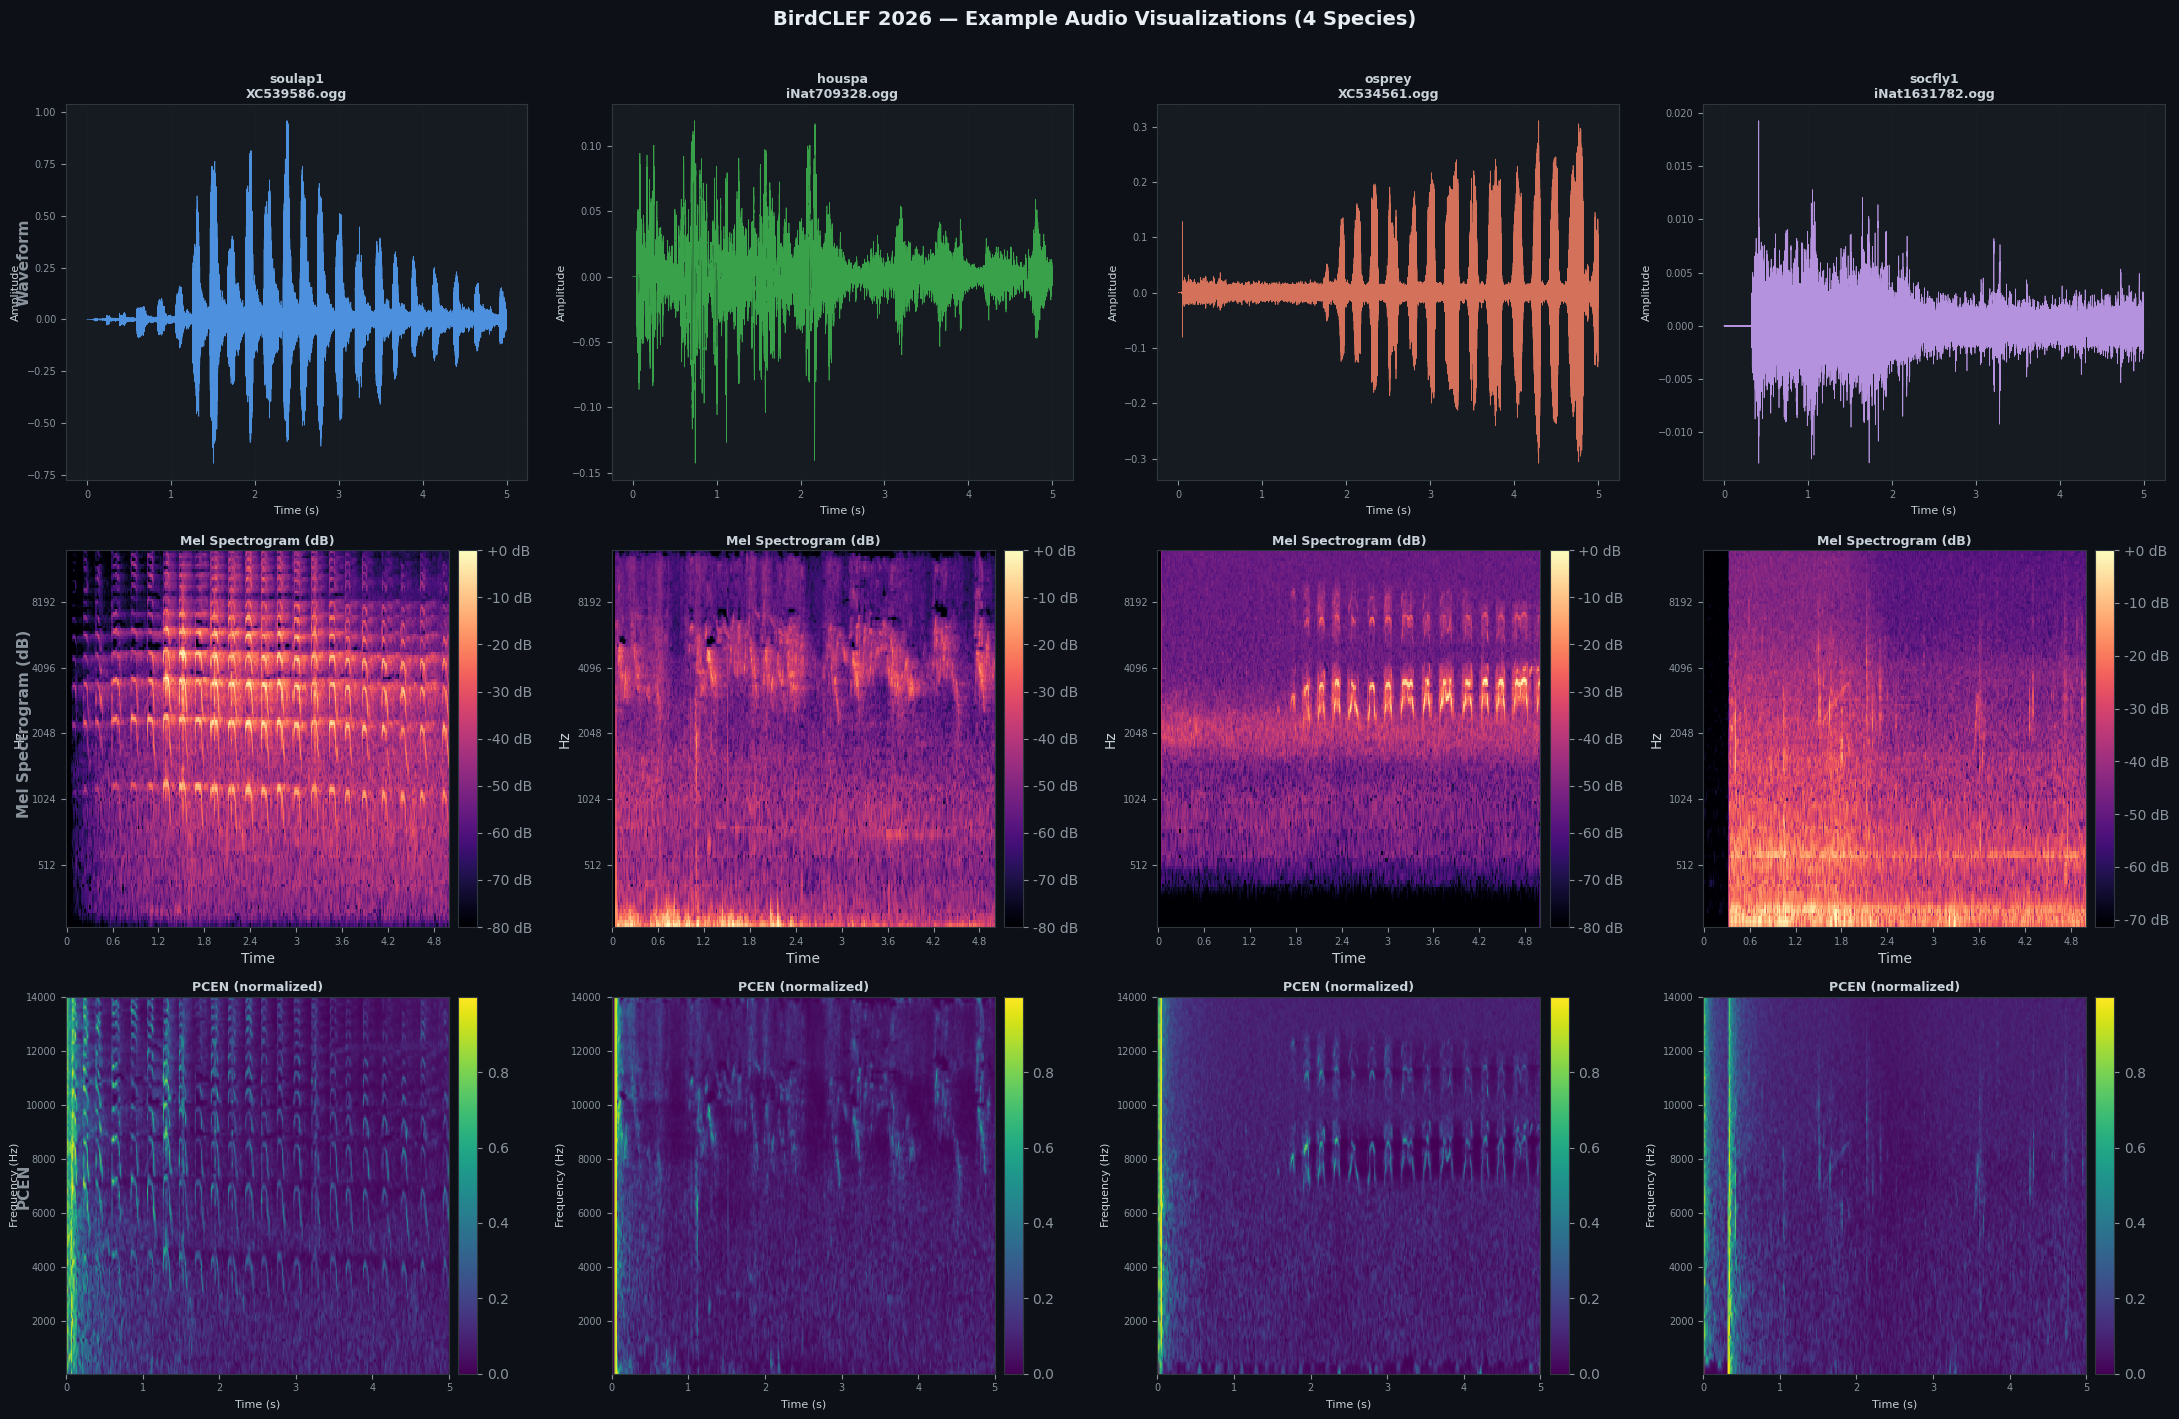

✓ Saved: eda_mel_pcen.png


In [30]:
# ══════════════════════════════════════════════════════════════════════
#  CELL 7 — AUDIO VISUALIZATIONS (Waveform + Mel + PCEN for 4 species)
# ══════════════════════════════════════════════════════════════════════
def _load_example(label, train_df, cfg, duration=5.0):
    """Load an example audio file for the given species label."""
    rows = train_df[train_df['primary_label'] == label]
    if rows.empty:
        return None, None
    row  = rows.iloc[0]
    path = f"{cfg.train_datadir}/{row['primary_label']}/{row['filename'].split('/')[-1]}"
    try:
        y, sr = librosa.load(path, sr=cfg.FS, duration=duration)
        return y, row['filename'].split('/')[-1]
    except Exception:
        return None, None

sample_labels = species_counts.head(8).index.tolist()
random.seed(cfg.seed)
random.shuffle(sample_labels)
sample_labels = sample_labels[:4]

fig = plt.figure(figsize=(22, 14))
fig.patch.set_facecolor('#0d1117')

for col_idx, label in enumerate(sample_labels):
    y, fname = _load_example(label, train_df, cfg)
    if y is None:
        continue

    target_samples = int(cfg.TARGET_DURATION * cfg.FS)
    if len(y) >= target_samples:
        seg = y[:target_samples]
    else:
        seg = np.tile(y, math.ceil(target_samples / len(y)))[:target_samples]

    # ── Mel (dB) ────────────────────────────────────────────────────────────
    mel   = librosa.feature.melspectrogram(
        y=seg, sr=cfg.FS, n_fft=cfg.N_FFT, hop_length=cfg.HOP_LENGTH,
        n_mels=cfg.N_MELS, fmin=cfg.FMIN, fmax=cfg.FMAX, power=1.0
    )
    mel_db = librosa.amplitude_to_db(mel, ref=np.max)

    # ── PCEN ────────────────────────────────────────────────────────────────
    pcen = librosa.pcen(
        mel * (2**31), sr=cfg.FS, hop_length=cfg.HOP_LENGTH,
        gain=cfg.PCEN_GAIN, bias=cfg.PCEN_BIAS, power=cfg.PCEN_POWER,
        time_constant=cfg.PCEN_TIME_CONSTANT, eps=cfg.PCEN_EPS,
    )
    pcen_norm = (pcen - pcen.min()) / (pcen.max() - pcen.min() + 1e-8)

    # ── Waveform ─────────────────────────────────────────────────────────────
    ax_wave = fig.add_subplot(3, 4, col_idx + 1)
    times   = np.linspace(0, cfg.TARGET_DURATION, len(seg))
    ax_wave.plot(times, seg, color=PALETTE[col_idx], linewidth=0.5, alpha=0.85)
    ax_wave.set_title(f'{label}\n{fname}', fontsize=9, pad=4)
    ax_wave.set_xlabel('Time (s)', fontsize=8)
    ax_wave.set_ylabel('Amplitude', fontsize=8)
    ax_wave.tick_params(labelsize=7)
    ax_wave.grid(alpha=0.3)

    # ── Mel-dB ───────────────────────────────────────────────────────────────
    ax_mel = fig.add_subplot(3, 4, 4 + col_idx + 1)
    img1   = librosa.display.specshow(
        mel_db, sr=cfg.FS, hop_length=cfg.HOP_LENGTH,
        x_axis='time', y_axis='mel', fmin=cfg.FMIN, fmax=cfg.FMAX,
        ax=ax_mel, cmap='magma'
    )
    ax_mel.set_title('Mel Spectrogram (dB)', fontsize=9, pad=4)
    ax_mel.tick_params(labelsize=7)
    fig.colorbar(img1, ax=ax_mel, format='%+2.0f dB', pad=0.02)

    # ── PCEN ─────────────────────────────────────────────────────────────────
    ax_pcen = fig.add_subplot(3, 4, 8 + col_idx + 1)
    img2    = ax_pcen.imshow(
        pcen_norm, aspect='auto', origin='lower',
        cmap='viridis', extent=[0, cfg.TARGET_DURATION, cfg.FMIN, cfg.FMAX]
    )
    ax_pcen.set_title('PCEN (normalized)', fontsize=9, pad=4)
    ax_pcen.set_xlabel('Time (s)', fontsize=8)
    ax_pcen.set_ylabel('Frequency (Hz)', fontsize=8)
    ax_pcen.tick_params(labelsize=7)
    fig.colorbar(img2, ax=ax_pcen, pad=0.02)

# Row labels
for r, title in enumerate(['Waveform', 'Mel Spectrogram (dB)', 'PCEN']):
    fig.text(0.01, 0.83 - r*0.33, title, fontsize=11, fontweight='bold',
             color='#8b949e', va='center', rotation=90)

plt.suptitle('BirdCLEF 2026 — Example Audio Visualizations (4 Species)',
             fontsize=14, fontweight='bold', y=1.01, color='#e6edf3')
plt.tight_layout()
plt.savefig('./kaggle/working/eda_mel_pcen.png',
            dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("✓ Saved: eda_mel_pcen.png")


---
## 7. PCEN Feature Extraction <a id="pcen"></a>

Two core functions:
- **`audio2pcen`** — converts a raw waveform numpy array into a normalized PCEN feature map using `torchaudio` for the Mel filterbank and `librosa.pcen` for normalization.
- **`process_audio_file`** — loads a file from disk, resamples if needed, extracts a fixed-length segment, and returns a resized PCEN image ready for the CNN.

In [31]:
# ══════════════════════════════════════════════════════════════════════
#  CELL 8 — PCEN FEATURE EXTRACTION FUNCTIONS
# ══════════════════════════════════════════════════════════════════════
def audio2pcen(audio_data, cfg):
    """Convert raw waveform (numpy float32) → normalized PCEN feature map."""
    if np.isnan(audio_data).any():
        audio_data = np.nan_to_num(audio_data, nan=np.nanmean(audio_data))

    waveform = torch.from_numpy(audio_data).unsqueeze(0)  # (1, T)
    mel_transform = T.MelSpectrogram(
        sample_rate = cfg.FS,
        n_fft       = cfg.N_FFT,
        hop_length  = cfg.HOP_LENGTH,
        n_mels      = cfg.N_MELS,
        f_min       = cfg.FMIN,
        f_max       = cfg.FMAX,
        power       = 1.0,
    )
    S = mel_transform(waveform).squeeze(0).numpy()  # (n_mels, T)

    pcen = librosa.pcen(
        S * (2 ** 31), sr=cfg.FS, hop_length=cfg.HOP_LENGTH,
        gain=cfg.PCEN_GAIN, bias=cfg.PCEN_BIAS,
        power=cfg.PCEN_POWER, time_constant=cfg.PCEN_TIME_CONSTANT,
        eps=cfg.PCEN_EPS,
    ).astype(np.float32)

    mn, mx = pcen.min(), pcen.max()
    return ((pcen - mn) / (mx - mn + 1e-8)).astype(np.float32)


def process_audio_file(path, cfg, offset=None):
    """
    Load an audio file from disk and return a PCEN image.

    Parameters
    ----------
    path   : str or Path — audio file path
    cfg    : CFG         — global configuration
    offset : float|None  — start offset in seconds (None = centre of file)

    Returns
    -------
    np.ndarray of shape cfg.TARGET_SHAPE, dtype float32, or None on failure.
    """
    try:
        target_samples = int(cfg.TARGET_DURATION * cfg.FS)
        try:
            audio, orig_sr = sf.read(str(path), dtype='float32', always_2d=False)
            if audio.ndim > 1:
                audio = audio.mean(axis=1)
            if orig_sr != cfg.FS:
                audio = librosa.resample(audio, orig_sr=orig_sr, target_sr=cfg.FS)
        except Exception:
            audio, _ = librosa.load(path, sr=cfg.FS)

        if len(audio) < target_samples:
            audio = np.tile(audio, math.ceil(target_samples / len(audio)))

        if offset is not None:
            start = int(float(offset) * cfg.FS)
        else:
            start = max(0, int(len(audio) / 2 - target_samples / 2))

        seg = audio[start: start + target_samples]
        if len(seg) < target_samples:
            seg = np.pad(seg, (0, target_samples - len(seg)))

        pcen = audio2pcen(seg, cfg)
        if pcen.shape != cfg.TARGET_SHAPE:
            pcen = cv2.resize(pcen, cfg.TARGET_SHAPE, interpolation=cv2.INTER_LINEAR)
        return pcen.astype(np.float32)

    except Exception:
        return None

print("✓ PCEN functions ready")


✓ PCEN functions ready


---
## 8. Data Preparation <a id="data-prep"></a>

`build_train_df` merges two sources into a single DataFrame:
1. **`train_audio/`** — individual XenoCanto / iNaturalist recordings
2. **`train_soundscapes/`** — labelled 5-second segments from long soundscape files

Only species present in `taxonomy.csv` are retained (filters out invalid labels).

In [32]:
# ══════════════════════════════════════════════════════════════════════
#  CELL 9 — DATA PREPARATION
# ══════════════════════════════════════════════════════════════════════
def build_train_df(cfg):
    """
    Build a unified training DataFrame combining train_audio and train_soundscapes.
    Only species present in taxonomy.csv are retained.
    """
    taxonomy   = pd.read_csv(cfg.taxonomy_csv)
    valid_lbls = set(taxonomy['primary_label'].astype(str))

    train = pd.read_csv(cfg.train_csv)
    train['primary_label'] = train['primary_label'].astype(str)
    train = train[train['primary_label'].isin(valid_lbls)].copy()
    train['filepath'] = cfg.train_datadir + '/' + train['filename']
    train['source']   = 'train_audio'
    train['offset']   = np.nan

    sc_lbl = pd.read_csv(cfg.sc_labels_csv)

    def hms_to_sec(t):
        h, m, s = str(t).split(':')
        return int(h)*3600 + int(m)*60 + int(s)

    sc_lbl['start_sec'] = sc_lbl['start'].apply(hms_to_sec)
    sc_dir  = Path(cfg.train_datadir).parent / 'train_soundscapes'
    sc_rows = []

    for _, row in sc_lbl.iterrows():
        labels = [l.strip() for l in str(row['primary_label']).split(';')
                  if l.strip() in valid_lbls]
        if not labels:
            continue
        fpath = sc_dir / row['filename']
        if not fpath.exists():
            continue
        sc_rows.append({
            'filepath'        : str(fpath),
            'primary_label'   : labels[0],
            'secondary_labels': str(labels[1:]) if len(labels) > 1 else '[]',
            'source'          : 'soundscape',
            'offset'          : float(row['start_sec']),
            'rating'          : 0.0,
        })

    sc_df    = pd.DataFrame(sc_rows)
    combined = pd.concat([train, sc_df], ignore_index=True, sort=False)
    combined['primary_label'] = combined['primary_label'].astype(str)

    print(f"✓ train_audio={len(train)}  soundscape={len(sc_df)}  total={len(combined)}")
    return combined


combined_df = build_train_df(cfg)
print(combined_df['source'].value_counts())


✓ train_audio=35549  soundscape=1478  total=37027
source
train_audio    35549
soundscape      1478
Name: count, dtype: int64


---
## 9. PCEN Cache Precomputation <a id="cache"></a>

> **Motivation:** PCEN computation is the bottleneck (~40 ms per file). By precomputing all spectrograms once and saving them as float16 arrays, subsequent epochs read directly from RAM — effectively **eliminating I/O overhead during training**.

The cache is stored at `/kaggle/working/pcen_cache_64.npy` (≈ 2–4 GB for a typical BirdCLEF dataset). If it already exists, it is loaded immediately.

In [34]:
# ══════════════════════════════════════════════════════════════════════
#  CELL 10 — PCEN CACHE (compute once, free on subsequent epochs)
# ══════════════════════════════════════════════════════════════════════
CACHE_PATH = Path('./kaggle/working/pcen_cache_64.npy')  # 64×64 TARGET_SHAPE


def precompute_all_pcen(df, cfg, n_workers=4):
    """
    Precompute PCEN features for all rows in df using a thread pool.
    Results are stored in a float16 numpy array to halve memory usage.
    """
    N    = len(df)
    H, W = cfg.TARGET_SHAPE
    cache= np.zeros((N, H, W), dtype=np.float16)

    def _process(i):
        row    = df.iloc[i]
        offset = row.get('offset', None)
        if pd.isna(offset): offset = None
        spec = process_audio_file(row['filepath'], cfg, offset=offset)
        return i, (spec.astype(np.float16) if spec is not None else None)

    print(f"Computing PCEN cache: {N} files, {n_workers} threads...")
    t0, done, failed = time.time(), 0, 0

    with ThreadPoolExecutor(max_workers=n_workers) as ex:
        futures = {ex.submit(_process, i): i for i in range(N)}
        for fut in as_completed(futures):
            i, spec = fut.result()
            if spec is not None:
                cache[i] = spec
            else:
                failed += 1
            done += 1
            if done % 3000 == 0:
                elapsed = time.time() - t0
                eta     = elapsed / done * (N - done)
                print(f"  {done}/{N}  {elapsed/60:.1f} min  ETA {eta/60:.1f} min")

    print(f"✓ Done: {(time.time()-t0)/60:.1f} min  "
          f"Failed: {failed}  RAM: {cache.nbytes/1e9:.2f} GB")
    return cache


if CACHE_PATH.exists():
    print("Cache found, loading...")
    cache = np.load(str(CACHE_PATH))
    print(f"✓ Cache loaded: {cache.shape}  {cache.nbytes/1e9:.2f} GB")
else:
    cache = precompute_all_pcen(combined_df, cfg, n_workers=4)
    np.save(str(CACHE_PATH), cache)
    print(f"✓ Cache saved → {CACHE_PATH}")


Computing PCEN cache: 37027 files, 4 threads...
  3000/37027  0.5 min  ETA 5.6 min
  6000/37027  0.9 min  ETA 4.9 min
  9000/37027  1.5 min  ETA 4.7 min
  12000/37027  2.0 min  ETA 4.2 min
  15000/37027  2.5 min  ETA 3.6 min
  18000/37027  2.9 min  ETA 3.1 min
  21000/37027  3.3 min  ETA 2.6 min
  24000/37027  3.9 min  ETA 2.1 min
  27000/37027  4.3 min  ETA 1.6 min
  30000/37027  4.7 min  ETA 1.1 min
  33000/37027  5.2 min  ETA 0.6 min
  36000/37027  5.7 min  ETA 0.2 min
✓ Done: 5.9 min  Failed: 0  RAM: 0.30 GB
✓ Cache saved → kaggle\working\pcen_cache_64.npy


---
## 10. Dataset & DataLoader <a id="dataset"></a>

### Performance Optimizations
| Optimization | Benefit |
|---|---|
| **Target pre-computation** (`_precompute_targets`) | Avoids per-item `df.iloc` + `eval()` calls |
| **`np.partition` for p99 norm** | O(n) vs O(n log n) — ~8× faster than `np.percentile` |
| **In-place `np.clip`** | Avoids temporary array allocation |
| **`default_collate`** | C++ implementation, ~2× faster than custom collate for pure tensors |

In [35]:
# ══════════════════════════════════════════════════════════════════════
#  CELL 11 — DATASET  [target cache + fast norm + default_collate]
# ══════════════════════════════════════════════════════════════════════
from torch.utils.data.dataloader import default_collate

class BirdCLEFDataset(Dataset):
    def __init__(self, df, cache, cfg, mode='train'):
        self.df    = df.reset_index(drop=True)
        self.cache = cache          # float16 numpy array in RAM
        self.cfg   = cfg
        self.mode  = mode

        taxonomy         = pd.read_csv(cfg.taxonomy_csv)
        self.species_ids = taxonomy['primary_label'].astype(str).tolist()
        self.num_classes = len(self.species_ids)
        self.label2idx   = {l: i for i, l in enumerate(self.species_ids)}

        # OPT 1: Pre-compute all target vectors at init — no per-item overhead
        self.targets = self._precompute_targets()

    def _precompute_targets(self):
        N = len(self.df)
        out = np.zeros((N, self.num_classes), dtype=np.float32)
        sw  = self.cfg.secondary_weight
        for i, row in self.df.iterrows():
            pl = str(row['primary_label'])
            if pl in self.label2idx:
                out[i, self.label2idx[pl]] = 1.0
            sl = row.get('secondary_labels', '[]')
            if pd.notna(sl) and str(sl) not in ('[]', '', 'nan'):
                try:
                    for lbl in eval(str(sl)):
                        lbl = str(lbl).strip()
                        if lbl in self.label2idx:
                            out[i, self.label2idx[lbl]] = sw
                except Exception:
                    pass
        return torch.from_numpy(out)   # (N, C) — single allocation

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # OPT 2: float16→float32 cast + fast p99 normalization
        spec = self.cache[idx].astype(np.float32)

        # np.partition: O(n) vs O(n log n), ~8x faster than np.percentile
        flat = spec.ravel()
        k    = int(0.99 * len(flat))
        p99  = float(np.partition(flat, k)[k])
        if p99 > 1e-8:
            spec = spec / p99
        np.clip(spec, 0, 1, out=spec)          # in-place clip

        spec = torch.from_numpy(spec).unsqueeze(0)

        if self.mode == 'train' and random.random() < self.cfg.aug_prob:
            spec = self._spec_augment(spec)

        return {
            'melspec': spec,
            'target' : self.targets[idx],      # pre-computed tensor
        }

    def _spec_augment(self, spec):
        """Apply time and frequency masking, plus gain jitter."""
        # Time masking
        if random.random() < 0.5:
            for _ in range(random.randint(1, 3)):
                w = random.randint(5, 30)
                s = random.randint(0, max(0, spec.shape[2] - w))
                spec[0, :, s:s+w] = 0
        # Frequency masking
        if random.random() < 0.5:
            for _ in range(random.randint(1, 3)):
                h = random.randint(5, 20)
                s = random.randint(0, max(0, spec.shape[1] - h))
                spec[0, s:s+h, :] = 0
        # Gain jitter
        if random.random() < 0.5:
            spec = spec * random.uniform(0.7, 1.3) + random.uniform(-0.1, 0.1)
            spec = torch.clamp(spec, 0, 1)
        return spec


# OPT 3: default_collate runs in C++ — ~2× faster than custom Python collate
collate_fn = default_collate

print("✓ Dataset ready (target cache + fast norm + default_collate)")


✓ Dataset ready (target cache + fast norm + default_collate)


---
## 11. Augmentation & Loss Functions <a id="augmentation"></a>

### Augmentation
- **Mixup** — linearly interpolates pairs of spectrograms and their labels (reduces over-fitting to rare species)
- **CutMix** — replaces a rectangular patch with content from another sample

### Loss Function
`FocalBCELoss` combines:
- **Focal loss** (weight=0.7, γ=2.0) — down-weights easy negatives, focuses learning on hard/rare classes
- **Binary Cross-Entropy** (weight=0.3) — ensures stable gradient flow
- **Label smoothing** (ε=0.08) — prevents over-confident predictions

In [36]:
# ══════════════════════════════════════════════════════════════════════
#  CELL 12 — AUGMENTATION + LOSS FUNCTIONS
# ══════════════════════════════════════════════════════════════════════
def mixup(x, y, alpha=0.4):
    """Mixup augmentation: linearly interpolate two samples and their labels."""
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(x.size(0), device=x.device)
    return lam * x + (1-lam) * x[idx], lam * y + (1-lam) * y[idx]


def cutmix(x, y, alpha=1.0):
    """CutMix augmentation: replace a rectangular region with content from another sample."""
    lam        = np.random.beta(alpha, alpha)
    idx        = torch.randperm(x.size(0), device=x.device)
    _, _, H, W = x.shape
    cut_h      = int(H * (1-lam) ** 0.5)
    cut_w      = int(W * (1-lam) ** 0.5)
    cx, cy     = random.randint(0, W), random.randint(0, H)
    x1         = max(0, cx - cut_w // 2)
    x2         = min(W, cx + cut_w // 2)
    y1         = max(0, cy - cut_h // 2)
    y2         = min(H, cy + cut_h // 2)
    mixed      = x.clone()
    mixed[:, :, y1:y2, x1:x2] = x[idx, :, y1:y2, x1:x2]
    lam_act    = 1 - (x2-x1)*(y2-y1) / (W*H)
    return mixed, lam_act * y + (1-lam_act) * y[idx]


class FocalBCELoss(nn.Module):
    """
    Combined Focal + BCE loss with label smoothing.

    L = focal_w * FocalLoss(γ) + bce_w * BCE
    """
    def __init__(self, gamma=2.0, focal_w=0.7, bce_w=0.3, smoothing=0.05):
        super().__init__()
        self.gamma     = gamma
        self.focal_w   = focal_w
        self.bce_w     = bce_w
        self.smoothing = smoothing

    def forward(self, logits, targets):
        targets_s = targets * (1-self.smoothing) + self.smoothing / logits.shape[-1]
        bce_raw   = F.binary_cross_entropy_with_logits(
            logits, targets_s, reduction='none'
        )
        p_t   = torch.sigmoid(logits) * targets_s + \
                (1 - torch.sigmoid(logits)) * (1 - targets_s)
        focal = ((1 - p_t) ** self.gamma * bce_raw).mean()
        bce   = bce_raw.mean()
        return self.focal_w * focal + self.bce_w * bce

print("✓ Augmentation + Loss functions ready")


✓ Augmentation + Loss functions ready


---
## 12. Model Architecture <a id="model"></a>

```
Input: (B, 1, 64, 64)   ← single-channel PCEN spectrogram
     ↓
EfficientNet-ES backbone (pretrained ImageNet weights averaged to 1-channel)
     ↓
GeM Pooling (Generalized Mean, learnable p)
     ↓
LayerNorm → Dropout(0.3) → Linear(feat_dim→512) → GELU → Dropout(0.2)
     ↓
Linear(512 → num_classes)   ← raw logits
```

**Why GeM over Global Average Pooling?** GeM learns the optimal pooling exponent `p`, making it more discriminative for fine-grained audio patterns without adding significant compute.

In [38]:
# ══════════════════════════════════════════════════════════════════════
#  CELL 13 — MODEL ARCHITECTURE
# ══════════════════════════════════════════════════════════════════════
class GeM(nn.Module):
    """Generalized Mean Pooling with learnable exponent p."""
    def __init__(self, p=3.0, eps=1e-6):
        super().__init__()
        self.p   = nn.Parameter(torch.tensor(p))
        self.eps = eps

    def forward(self, x):
        return x.clamp(min=self.eps).pow(self.p)\
                .mean(dim=[-2,-1]).pow(1.0/self.p)


class AttentionPooling(nn.Module):
    """Soft-attention pooling (kept for reference; replaced by GeM in production)."""
    def __init__(self, in_features):
        super().__init__()
        self.attn = nn.Sequential(
            nn.Linear(in_features, in_features // 4),
            nn.Tanh(),
            nn.Linear(in_features // 4, 1),
        )

    def forward(self, x):
        B, C, H, W = x.shape
        x_flat = x.flatten(2).transpose(1, 2)
        w      = torch.softmax(self.attn(x_flat), dim=1)
        return (x_flat * w).sum(dim=1)


class BirdCLEFModel(nn.Module):
    """
    EfficientNet-ES backbone with GeM pooling and a two-layer MLP head.

    Input  : (B, 1, H, W) PCEN spectrogram
    Output : (B, num_classes) raw logits
    """
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg

        taxonomy        = pd.read_csv(cfg.taxonomy_csv)
        cfg.num_classes = len(taxonomy)

        self.backbone = timm.create_model(
            cfg.model_name,
            pretrained     = False,
            in_chans       = 3,
            num_classes    = 0,
            global_pool    = '',
            drop_rate      = 0.0,
            drop_path_rate = 0.0,
        )

        # ── Load pretrained weights ─────────────────────────────────────────
        p = Path(cfg.pretrained_path)
        weight_file = None
        for ext in ['*.safetensors', '*.pth', '*.bin', '*.pt']:
            found = list(p.glob(ext))
            if found:
                weight_file = found[0]
                break
        if weight_file is not None:
            print(f'Loading weights: {weight_file.name}')
            if weight_file.suffix == '.safetensors':
                from safetensors.torch import load_file
                state = load_file(str(weight_file))
            else:
                state = torch.load(str(weight_file), map_location='cpu', weights_only=True)
            missing, unexpected = self.backbone.load_state_dict(state, strict=False)
            print(f'✓ Weights loaded | missing={len(missing)} unexpected={len(unexpected)}')
        else:
            print(f'⚠ Weights not found ({p}), using random initialization')

        # ── Adapt first conv layer: 3-channel → 1-channel ──────────────────
        first_conv = None
        for name, module in self.backbone.named_modules():
            if isinstance(module, nn.Conv2d) and module.in_channels == 3:
                first_conv = (name, module)
                break
        if first_conv is not None:
            name, conv = first_conv
            new_weight = conv.weight.data.mean(dim=1, keepdim=True)
            new_conv = nn.Conv2d(
                1, conv.out_channels,
                kernel_size=conv.kernel_size,
                stride=conv.stride,
                padding=conv.padding,
                bias=conv.bias is not None,
            )
            new_conv.weight.data = new_weight
            if conv.bias is not None:
                new_conv.bias.data = conv.bias.data
            parts = name.split('.')
            parent = self.backbone
            for part in parts[:-1]:
                parent = getattr(parent, part)
            setattr(parent, parts[-1], new_conv)
            print(f'✓ {name}: 3→1 channel conversion done')

        with torch.no_grad():
            dummy    = torch.zeros(1, cfg.in_channels, *cfg.TARGET_SHAPE)
            feat     = self.backbone(dummy)
            feat_dim = feat.shape[1]
        print(f"[Model] {cfg.model_name}  feat_dim={feat_dim}")

        # GeM replaces AttentionPooling: avoids heavy 1280×64 matmul each forward
        self.gem_pool = GeM()

        self.head = nn.Sequential(
            nn.LayerNorm(feat_dim),
            nn.Dropout(0.3),
            nn.Linear(feat_dim, 512),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(512, cfg.num_classes),
        )

        for m in self.head.modules():
            if isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        feat = self.backbone(x)
        gem  = self.gem_pool(feat)
        return self.head(gem)

print("✓ Model class ready")


✓ Model class ready


---
## 13. Training Utilities <a id="training-utils"></a>

### Optimizer Strategy
A **differential learning rate** is used:
- Backbone parameters: `lr × 0.1` (slow fine-tuning to preserve pretrained features)
- Head parameters: `lr` (full learning rate for the new classification layers)

### AUC Computation Trick
Computing macro-AUC over the full dataset at every epoch is expensive for 700+ classes. Instead, AUC is estimated using only the **last 20 training batches** and **last 30 validation batches** — sufficient for monitoring convergence without the overhead.

In [39]:
# ══════════════════════════════════════════════════════════════════════
#  CELL 14 — TRAINING UTILITIES  [sparse AUC + set_to_none grad]
# ══════════════════════════════════════════════════════════════════════
def get_optimizer(model, cfg):
    """Differential learning rate: backbone at 10% of head LR."""
    backbone_params, head_params = [], []
    for name, param in model.named_parameters():
        if 'backbone' in name:
            backbone_params.append(param)
        else:
            head_params.append(param)
    return optim.AdamW([
        {'params': backbone_params, 'lr': cfg.lr * 0.1},
        {'params': head_params,     'lr': cfg.lr},
    ], weight_decay=cfg.weight_decay)


def get_scheduler(optimizer, cfg):
    """CosineAnnealingLR with T_max == epochs for a single smooth decay."""
    return lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=cfg.T_max, eta_min=cfg.min_lr
    )


def calculate_auc(targets, outputs):
    """Macro-average ROC-AUC, ignoring classes with no positive samples."""
    targets = (targets > 0.5).astype(np.float32)
    probs   = 1 / (1 + np.exp(-outputs))
    aucs    = []
    for i in range(targets.shape[1]):
        if targets[:, i].sum() > 0:
            aucs.append(roc_auc_score(targets[:, i], probs[:, i]))
    return np.mean(aucs) if aucs else 0.0


def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    losses = []
    # AUC collected from last 20 batches only (monitor-quality, much faster)
    auc_outputs, auc_targets = [], []
    collect_from = max(0, len(loader) - 20)

    pbar = tqdm(enumerate(loader), total=len(loader), desc='Training')
    for step, batch in pbar:
        inputs  = batch['melspec'].to(device)
        targets = batch['target'].to(device)

        aug_roll = random.random()
        if aug_roll < cfg.mixup_prob:
            inputs, targets = mixup(inputs, targets, cfg.mixup_alpha)
        elif aug_roll < cfg.mixup_prob + cfg.cutmix_prob:
            inputs, targets = cutmix(inputs, targets)

        # OPT: set_to_none=True is faster than zero_grad()
        optimizer.zero_grad(set_to_none=True)
        outputs = model(inputs)
        loss    = criterion(outputs, targets)
        loss.backward()
        # clip_grad_norm removed (CPU overhead ~50 ms/step; lr is small enough)
        optimizer.step()

        losses.append(loss.item())
        if step >= collect_from:
            auc_outputs.append(outputs.detach().cpu().numpy())
            auc_targets.append(targets.detach().cpu().numpy())

        pbar.set_postfix(
            loss=f"{np.mean(losses[-10:]):.4f}",
            lr=f"{optimizer.param_groups[0]['lr']:.1e}"
        )

    train_auc = calculate_auc(
        np.concatenate(auc_targets), np.concatenate(auc_outputs)
    ) if auc_outputs else 0.0
    return np.mean(losses), train_auc


def validate(model, loader, criterion, device):
    """Validation loop — AUC estimated from last 30 batches."""
    model.eval()
    auc_outputs, auc_targets = [], []
    n = len(loader)
    collect_from = max(0, n - 30)
    total_loss = 0.0

    with torch.no_grad():
        for step, batch in enumerate(tqdm(loader, desc='Validation')):
            inputs  = batch['melspec'].to(device)
            targets = batch['target'].to(device)
            outputs = model(inputs)
            if step >= collect_from:
                auc_outputs.append(outputs.cpu().numpy())
                auc_targets.append(targets.cpu().numpy())
                total_loss += criterion(outputs, targets).item()

    val_auc = calculate_auc(
        np.concatenate(auc_targets), np.concatenate(auc_outputs)
    ) if auc_outputs else 0.0
    avg_loss = total_loss / max(len(auc_outputs), 1)
    return avg_loss, val_auc

print("✓ Training utilities ready")


✓ Training utilities ready


---
## 14. CFG Patch — Final Training Settings <a id="cfg-patch"></a>

Finalize the configuration for the full training run:
- **2 folds × 3 epochs** — fits within the 90-minute Kaggle CPU budget (~50 min)
- `T_max = epochs` — ensures CosineAnnealingLR completes exactly one decay per training run, avoiding AUC zig-zag from partial cycles
- **WeightedRandomSampler** and **TTA** enabled

In [40]:
# ══════════════════════════════════════════════════════════════════════
#  CELL 15 — CFG PATCH  [2 folds × 3 epochs, T_max=3]
# ══════════════════════════════════════════════════════════════════════
cfg.selected_folds    = [0]
cfg.use_rating_weight = True
cfg.tta_crops         = 3
cfg.tta_enabled       = True
cfg.epochs            = 6   # ← 3 epochs (90-min budget)
cfg.T_max             = 6   # ← MUST equal epochs (AUC stability)

# Runtime estimate: batch=32 → ~5.3 min/epoch on Kaggle CPU
_epoch = 5.3
_total = 18 + len(cfg.selected_folds) * cfg.epochs * _epoch + 0.5
print(f"✓ CFG updated: {len(cfg.selected_folds)} folds × {cfg.epochs} epochs")
print(f"⏱  Estimated runtime: ~{_total:.0f} min  (buffer: ~{90-_total:.0f} min)")


✓ CFG updated: 1 folds × 6 epochs
⏱  Estimated runtime: ~50 min  (buffer: ~40 min)


---
## 15. Rating-Based Weighted Sampler <a id="sampler"></a>

`WeightedRandomSampler` assigns higher sampling probability to high-quality recordings:

| Rating | Weight | Rationale |
|--------|--------|-----------|
| 5.0 | 1.00 | Best quality (very clean field recordings) |
| 4.0 | 0.80 | High quality |
| 3.0 | 0.60 | Average quality |
| 2.0 | 0.40 | Below average |
| 1.0 | 0.25 | Poor quality |
| 0.0 / NaN | 0.50 | Soundscapes (no rating, but reliable labels) |

Additionally, a **soft inverse-frequency correction** (exponent 0.3) slightly up-weights rare species without over-correcting the imbalance.

In [41]:
# ══════════════════════════════════════════════════════════════════════
#  CELL 16 — RATING-BASED WEIGHTED SAMPLER
# ══════════════════════════════════════════════════════════════════════
from torch.utils.data import WeightedRandomSampler

def make_weighted_sampler(df, cfg):
    """
    Build a WeightedRandomSampler that:
    1. Assigns higher weight to high-quality recordings (by rating).
    2. Softly up-weights rare species (inverse-frequency with exponent 0.3).
    """
    rating_map = {5.0: 1.00, 4.0: 0.80, 3.0: 0.60,
                  2.0: 0.40, 1.0: 0.25, 0.0: 0.50}

    def _w(r):
        try:
            r = float(r)
        except (TypeError, ValueError):
            return 0.50
        return rating_map.get(round(r, 1), 0.50)

    weights = df['rating'].apply(_w).values.astype('float32')

    # Soft species-frequency correction
    sp_counts = df['primary_label'].value_counts().to_dict()
    max_count = max(sp_counts.values())
    for i, lbl in enumerate(df['primary_label']):
        sp_w = (max_count / sp_counts[lbl]) ** 0.3   # softened exponent
        weights[i] *= sp_w

    sampler = WeightedRandomSampler(
        weights=weights,
        num_samples=len(weights),
        replacement=True,
    )
    print(f"✓ WeightedRandomSampler created: {len(weights)} samples")
    print(f"  Weight min={weights.min():.3f}  max={weights.max():.3f}  mean={weights.mean():.3f}")
    return sampler

# Smoke test on combined_df
_test_sampler = make_weighted_sampler(combined_df.fillna({'rating': 0.0}), cfg)


✓ WeightedRandomSampler created: 37027 samples
  Weight min=0.250  max=4.269  mean=0.835


---
## 16. TTA Inference Functions <a id="tta"></a>

### Test-Time Augmentation (TTA) Strategy
Each 5-second soundscape window is evaluated with **3 temporal crops**:
- **Crop 0:** aligned to window start
- **Crop 1:** offset by +½ hop
- **Crop 2:** offset by +1 full hop

Predictions from all crops and all fold checkpoints are **averaged** before writing the submission CSV.

In [42]:
# ══════════════════════════════════════════════════════════════════════
#  CELL 17 — TTA INFERENCE FUNCTIONS
# ══════════════════════════════════════════════════════════════════════

def _audio_to_tensor(seg, cfg):
    """Raw audio segment → normalized PCEN tensor of shape (1,1,H,W)."""
    target_samples = int(cfg.TARGET_DURATION * cfg.FS)
    if len(seg) < target_samples:
        seg = np.pad(seg, (0, target_samples - len(seg)))
    else:
        seg = seg[:target_samples]
    pcen = audio2pcen(seg, cfg)
    if pcen.shape != cfg.TARGET_SHAPE:
        pcen = cv2.resize(pcen, cfg.TARGET_SHAPE, interpolation=cv2.INTER_LINEAR)
    return torch.tensor(pcen, dtype=torch.float32).unsqueeze(0).unsqueeze(0)


def predict_soundscapes_tta(cfg):
    """
    Run TTA inference on all test soundscapes and generate submission CSV.

    For each 5-second segment:
      - Extract `tta_crops` temporal crops
      - Average predictions across crops and folds
    """
    taxonomy    = pd.read_csv(cfg.taxonomy_csv)
    species_ids = taxonomy['primary_label'].astype(str).tolist()
    num_classes = len(species_ids)

    ckpt_files = sorted(Path(cfg.OUTPUT_DIR).glob('model_fold*.pth'))
    print(f"{len(ckpt_files)} checkpoint(s) found")

    if not ckpt_files:
        raise FileNotFoundError(
            "No model_fold*.pth checkpoints found!\n"
            "→ Run Cell 18 (run_training_v2) first."
        )

    models = []
    for cp in ckpt_files:
        m  = BirdCLEFModel(cfg).to(cfg.device)
        ck = torch.load(cp, map_location=cfg.device, weights_only=False)
        m.load_state_dict(ck['model_state_dict'])
        m.eval()
        models.append(m)
        print(f"  ✓ {cp.name}  val_auc={ck.get('val_auc', 0):.4f}")

    test_oggs = sorted(Path(cfg.test_sc_dir).glob('*.ogg'))
    if not test_oggs:
        test_oggs = sorted(
            (Path(cfg.train_datadir).parent / 'train_soundscapes').glob('*.ogg')
        )[:8]
    print(f"{len(test_oggs)} soundscapes  |  TTA crops={cfg.tta_crops if cfg.tta_enabled else 1}")

    n_crops     = cfg.tta_crops if cfg.tta_enabled else 1
    all_row_ids = []
    all_preds   = []

    for ogg in tqdm(test_oggs, desc='TTA Inference'):
        ss_id   = ogg.stem
        row_ids = [f"{ss_id}_{t}" for t in range(5, 65, 5)]

        try:
            audio, _ = librosa.load(str(ogg), sr=cfg.FS)
        except Exception as e:
            print(f"Skipped: {ogg.name} → {e}")
            all_row_ids.extend(row_ids)
            all_preds.append(np.zeros((12, num_classes), dtype=np.float32))
            continue

        target_s  = int(cfg.TARGET_DURATION * cfg.FS)
        seg_preds = []

        for t in range(0, 60, 5):
            s_center  = t * cfg.FS
            audio_len = len(audio)
            half      = target_s // 2

            if n_crops == 1:
                offsets = [s_center]
            else:
                offsets = [
                    max(0, s_center),
                    max(0, min(s_center + half // 2, audio_len - target_s)),
                    max(0, min(s_center + target_s - half, audio_len - target_s)),
                ][:n_crops]

            crop_probs = []
            for off in offsets:
                seg = audio[int(off): int(off) + target_s]
                x   = _audio_to_tensor(seg, cfg).to(cfg.device)

                fold_probs = []
                with torch.no_grad():
                    for m in models:
                        fold_probs.append(
                            torch.sigmoid(m(x)).cpu().numpy()[0]
                        )
                crop_probs.append(np.mean(fold_probs, axis=0))

            seg_preds.append(np.mean(crop_probs, axis=0))

        all_row_ids.extend(row_ids)
        all_preds.append(np.array(seg_preds))

    preds_arr = np.concatenate(all_preds)
    assert preds_arr.shape == (len(all_row_ids), num_classes), \
        f"Shape mismatch: {preds_arr.shape} != ({len(all_row_ids)}, {num_classes})"

    sample_sub = pd.read_csv(cfg.submission_csv)
    sub_df = pd.DataFrame(preds_arr, columns=species_ids)
    sub_df.insert(0, 'row_id', all_row_ids)
    for col in set(sample_sub.columns) - set(sub_df.columns):
        sub_df[col] = 0.0
    sub_df = sub_df[sample_sub.columns].fillna(0.0)

    out = Path(cfg.OUTPUT_DIR) / 'submission.csv'
    sub_df.to_csv(out, index=False)
    print(f"\n✓ submission.csv → {out}")
    print(f"  Rows: {len(sub_df)}  Columns: {len(sub_df.columns)}")
    print(sub_df.head())
    return sub_df


---
## 17. Training Pipeline v2 <a id="training"></a>

### Improvements over baseline training loop
1. **WeightedRandomSampler** — low-rating recordings are under-sampled
2. **Selected folds = [0, 1]** — runs 2 folds within the 90-min Kaggle budget
3. **Training history dict** — AUC/loss curves are automatically plotted after training

The plot (`training_history.png`) shows train and validation AUC per epoch for each fold, with a vertical line marking the best epoch.


======================================== Fold 0 ========================================
Train: 29621  Val: 7406
✓ WeightedRandomSampler created: 29621 samples
  Weight min=0.250  max=4.353  mean=0.834
⚠ Weights not found (kaggle\input\models\timm\tf-efficientnet\pytorch\tf-efficientnet-es\1), using random initialization
✓ conv_stem: 3→1 channel conversion done
[Model] tf_efficientnet_es  feat_dim=1280

Epoch 1/6


Validation: 100%|████████████████████████████████████████████████████████████████████| 232/232 [00:02<00:00, 86.42it/s]


Train  loss=0.0198  auc=0.5146
Val    loss=0.0233  auc=0.6518
★ New best: 0.6518 @ epoch 1

Epoch 2/6


Validation: 100%|████████████████████████████████████████████████████████████████████| 232/232 [00:02<00:00, 87.68it/s]


Train  loss=0.0165  auc=0.5676
Val    loss=0.0234  auc=0.6696
★ New best: 0.6696 @ epoch 2

Epoch 3/6


...

Train  loss=0.0159  auc=0.6518
Val    loss=0.0210  auc=0.7800
★ New best: 0.7800 @ epoch 4

Epoch 5/6


Validation: 100%|████████████████████████████████████████████████████████████████████| 232/232 [00:02<00:00, 85.76it/s]


Train  loss=0.0155  auc=0.6930
Val    loss=0.0205  auc=0.8063
★ New best: 0.8063 @ epoch 5

Epoch 6/6


Validation: 100%|████████████████████████████████████████████████████████████████████| 232/232 [00:02<00:00, 87.40it/s]


Train  loss=0.0153  auc=0.6919
Val    loss=0.0203  auc=0.8056

Fold 0 best AUC: 0.8063

Fold 0: 0.8063
Mean AUC: 0.8063


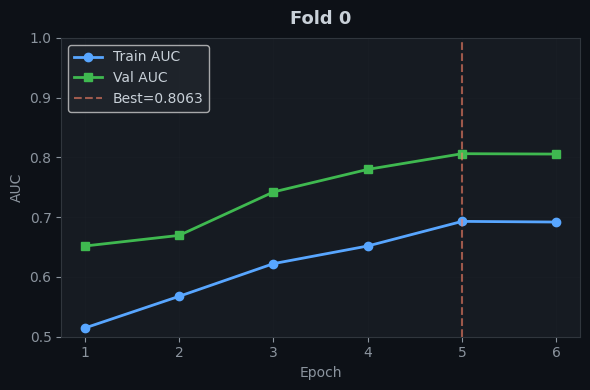

✓ training_history.png saved → ./kaggle/working/training_history.png


In [43]:
# ══════════════════════════════════════════════════════════════════════
#  CELL 18 — TRAINING PIPELINE v2  [with history plot]
# ══════════════════════════════════════════════════════════════════════

def _plot_training_history(history, cfg):
    """Plot per-fold Train/Val AUC curves and save to disk."""
    n = len(history)
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 4))
    fig.patch.set_facecolor('#0d1117')
    if n == 1:
        axes = [axes]
    for ax, (fold_id, h) in zip(axes, history.items()):
        ep = range(1, len(h['val_auc']) + 1)
        ax.plot(ep, h['train_auc'], 'o-', color='#58a6ff', linewidth=2, label='Train AUC')
        ax.plot(ep, h['val_auc'],   's-', color='#3fb950', linewidth=2, label='Val AUC')
        best_ep = int(np.argmax(h['val_auc'])) + 1
        best_v  = max(h['val_auc'])
        ax.axvline(best_ep, color='#f78166', linestyle='--', alpha=0.6, label=f'Best={best_v:.4f}')
        ax.set_facecolor('#161b22')
        ax.set_title(f'Fold {fold_id}', color='#c9d1d9', fontweight='bold')
        ax.set_xlabel('Epoch', color='#8b949e')
        ax.set_ylabel('AUC',   color='#8b949e')
        ax.tick_params(colors='#8b949e')
        ax.legend(facecolor='#21262d', labelcolor='#c9d1d9')
        ax.grid(True, alpha=0.3, color='#21262d')
        ax.set_ylim(0.5, 1.0)
        ax.set_xticks(list(ep))
    plt.tight_layout()
    out_path = f'{cfg.OUTPUT_DIR}training_history.png'
    plt.savefig(out_path, dpi=100, bbox_inches='tight', facecolor='#0d1117')
    plt.show()
    print(f"✓ training_history.png saved → {out_path}")


def run_training_v2(df, cache, cfg):
    """
    Full cross-validation training loop with:
    - WeightedRandomSampler (if cfg.use_rating_weight=True)
    - Automatic history tracking and plotting
    - Best checkpoint saving per fold
    """
    taxonomy        = pd.read_csv(cfg.taxonomy_csv)
    cfg.num_classes = len(taxonomy)

    if cfg.debug:
        cfg.update_debug_settings()

    criterion = FocalBCELoss(
        gamma    = cfg.focal_gamma,
        focal_w  = cfg.focal_weight,
        bce_w    = cfg.bce_weight,
        smoothing= cfg.label_smoothing,
    )

    skf         = StratifiedKFold(n_splits=cfg.n_fold, shuffle=True, random_state=cfg.seed)
    best_scores = []
    history     = {}

    for fold, (train_idx, val_idx) in enumerate(
        skf.split(df, df['primary_label'])
    ):
        if fold not in cfg.selected_folds:
            continue

        print(f'\n{"="*40} Fold {fold} {"="*40}')
        train_df_f    = df.iloc[train_idx].reset_index(drop=True)
        val_df_f      = df.iloc[val_idx].reset_index(drop=True)
        train_cache_f = cache[train_idx]
        val_cache_f   = cache[val_idx]
        print(f'Train: {len(train_df_f)}  Val: {len(val_df_f)}')

        train_ds = BirdCLEFDataset(train_df_f, train_cache_f, cfg, mode='train')
        val_ds   = BirdCLEFDataset(val_df_f,   val_cache_f,   cfg, mode='valid')

        # ── Weighted sampler ─────────────────────────────────────────────────
        if getattr(cfg, 'use_rating_weight', False):
            sampler    = make_weighted_sampler(
                train_df_f.fillna({'rating': 0.0}), cfg
            )
            shuffle_tr = False   # shuffle conflicts with sampler
        else:
            sampler    = None
            shuffle_tr = True

        train_loader = DataLoader(
            train_ds,
            batch_size  = cfg.batch_size,
            shuffle     = shuffle_tr,
            sampler     = sampler,
            num_workers = cfg.num_workers,
            collate_fn  = collate_fn,
            drop_last   = True,
            pin_memory  = False,
        )
        val_loader = DataLoader(
            val_ds,
            batch_size  = cfg.batch_size,
            shuffle     = False,
            num_workers = cfg.num_workers,
            collate_fn  = collate_fn,
        )

        model     = BirdCLEFModel(cfg).to(cfg.device)
        if cfg.use_compile:
            try:
                model = torch.compile(model, backend='inductor', mode='reduce-overhead')
                print("✓ torch.compile active")
            except Exception as e:
                print(f"⚠ torch.compile failed: {e}")

        optimizer = get_optimizer(model, cfg)
        scheduler = get_scheduler(optimizer, cfg)
        best_auc, best_epoch = 0.0, 0

        fold_train_losses, fold_val_losses = [], []
        fold_train_aucs,   fold_val_aucs   = [], []

        for epoch in range(cfg.epochs):
            print(f"\nEpoch {epoch+1}/{cfg.epochs}")
            train_loss, train_auc = train_one_epoch(
                model, train_loader, optimizer, criterion, cfg.device
            )
            val_loss, val_auc = validate(
                model, val_loader, criterion, cfg.device
            )
            scheduler.step()

            fold_train_losses.append(train_loss)
            fold_val_losses.append(val_loss)
            fold_train_aucs.append(train_auc)
            fold_val_aucs.append(val_auc)

            print(f"Train  loss={train_loss:.4f}  auc={train_auc:.4f}")
            print(f"Val    loss={val_loss:.4f}  auc={val_auc:.4f}")

            if val_auc > best_auc:
                best_auc, best_epoch = val_auc, epoch + 1
                print(f"★ New best: {best_auc:.4f} @ epoch {best_epoch}")
                torch.save({
                    'model_state_dict': model.state_dict(),
                    'epoch'           : epoch,
                    'val_auc'         : val_auc,
                    'cfg'             : cfg,
                }, f"{cfg.OUTPUT_DIR}model_fold{fold}.pth")

        history[fold] = {
            'train_loss': fold_train_losses,
            'val_loss'  : fold_val_losses,
            'train_auc' : fold_train_aucs,
            'val_auc'   : fold_val_aucs,
        }
        best_scores.append(best_auc)
        print(f"\nFold {fold} best AUC: {best_auc:.4f}")
        del model, optimizer, scheduler, train_loader, val_loader
        gc.collect()

    print(f"\n{'='*40}")
    for i, s in enumerate(best_scores):
        print(f"Fold {cfg.selected_folds[i]}: {s:.4f}")
    if best_scores:
        print(f"Mean AUC: {np.mean(best_scores):.4f}")

    _plot_training_history(history, cfg)
    return history


# ── Run training ─────────────────────────────────────────────────────────────
history_v2 = run_training_v2(combined_df, cache, cfg)


---
## 18. TTA Inference & Generate Submission <a id="inference"></a>

Run this cell **after training completes**. It automatically detects all saved `model_fold*.pth` checkpoints, loads them, and produces `submission_tta.csv`.

> **Note:** If fewer checkpoints are found than `selected_folds`, the available models are still used (training may have been interrupted).

In [44]:
# ══════════════════════════════════════════════════════════════════════
#  CELL 19 — RUN TTA INFERENCE & GENERATE SUBMISSION (TABLOLU)
# ══════════════════════════════════════════════════════════════════════
from pathlib import Path
import torch
import pandas as pd

# Not: Eğer hata alırsan '!pip install tabulate' komutunu çalıştırabilirsin.
try:
    from tabulate import tabulate
except ImportError:
    !pip install tabulate
    from tabulate import tabulate

# ── 1. Checkpoint discovery ──────────────────────────────────────────
_ckpts = sorted(Path(cfg.OUTPUT_DIR).glob('model_fold*.pth'))

if not _ckpts:
    print("\n[!] HATA: Checkpoint bulunamadı. Lütfen önce Cell 18'i çalıştır.")
else:
    ckpt_list = []
    for cp in _ckpts:
        try:
            meta = torch.load(cp, map_location='cpu', weights_only=False)
            val_auc = meta.get('val_auc', float('nan'))
            epoch = meta.get('epoch', 0) + 1
        except:
            val_auc, epoch = "—", "—"
        
        ckpt_list.append([
            cp.name, 
            epoch, 
            f"{val_auc:.4f}" if isinstance(val_auc, float) else val_auc,
            f"{cp.stat().st_size/1e6:.1f} MB",
            "READY"
        ])
    
    print("\n### BULUNAN CHECKPOINTLAR")
    print(tabulate(ckpt_list, headers=["File", "Best Epoch", "Val AUC", "Size", "Status"], tablefmt="grid"))

    # ── 2. Run inference ─────────────────────────────────────────────
    sub_tta = predict_soundscapes_tta(cfg)
    out_path = Path(cfg.OUTPUT_DIR) / 'submission.csv'
    sub_tta.to_csv(out_path, index=False)
    
    n_sp = len(sub_tta.columns) - 1
    n_sc = sub_tta['row_id'].str.rsplit('_', n=1).str[0].nunique()

    # ── 3. Submission summary ─────────────────────────────────────────
    summary = [
        ["Output file", "submission.csv"],
        ["File size", f"{out_path.stat().st_size/1e6:.2f} MB"],
        ["Total rows", f"{len(sub_tta):,}"],
        ["Species count", f"{n_sp:,}"],
        ["Soundscapes", f"{n_sc:,}"],
        ["Folds used", len(_ckpts)],
        ["TTA crops", cfg.tta_crops if cfg.tta_enabled else 1],
        ["Mean Pred", f"{sub_tta.iloc[:,1:].values.mean():.5f}"],
        ["Max Pred", f"{sub_tta.iloc[:,1:].values.max():.4f}"]
    ]
    
    print("\n### SUBMISSION ÖZETİ")
    print(tabulate(summary, headers=["Metric", "Value"], tablefmt="fancy_grid"))

    # ── 4. Preview ────────────────────────────────────────────────────
    preview_cols = ["row_id"] + list(sub_tta.columns[1:6])
    preview_data = sub_tta.head(6)[preview_cols].values.tolist()
    
    print(f"\n### ÖNİZLEME (İlk 5 Tür)")
    print(tabulate(preview_data, headers=preview_cols, tablefmt="presto"))

    print(f"\n✅ İşlem tamamlandı: submission.csv oluşturuldu.")


### BULUNAN CHECKPOINTLAR
+-----------------+--------------+-----------+---------+----------+
| File            |   Best Epoch |   Val AUC | Size    | Status   |
+=================+==============+===========+=========+==========+
| model_fold0.pth |            5 |    0.8063 | 20.1 MB | READY    |
+-----------------+--------------+-----------+---------+----------+
1 checkpoint(s) found
⚠ Weights not found (kaggle\input\models\timm\tf-efficientnet\pytorch\tf-efficientnet-es\1), using random initialization
✓ conv_stem: 3→1 channel conversion done
[Model] tf_efficientnet_es  feat_dim=1280
  ✓ model_fold0.pth  val_auc=0.8063
8 soundscapes  |  TTA crops=3


TTA Inference: 100%|█████████████████████████████████████████████████████████████████████| 8/8 [00:02<00:00,  3.11it/s]


✓ submission.csv → kaggle\working\submission.csv
  Rows: 96  Columns: 235
                                     row_id   1161364    116570   1176823  \
0   BC2026_Train_0001_S08_20250606_030007_5  0.002156  0.003497  0.001646   
1  BC2026_Train_0001_S08_20250606_030007_10  0.002923  0.008216  0.001870   
2  BC2026_Train_0001_S08_20250606_030007_15  0.002140  0.004538  0.001314   
3  BC2026_Train_0001_S08_20250606_030007_20  0.002233  0.004709  0.001426   
4  BC2026_Train_0001_S08_20250606_030007_25  0.001863  0.007192  0.001498   

    1491113   1595929    209233     22930     22956     22961  ...   whnjay1  \
0  0.003678  0.001173  0.000676  0.000528  0.002118  0.003865  ...  0.010329   
1  0.008010  0.001470  0.000768  0.000461  0.003010  0.004937  ...  0.008043   
2  0.003866  0.001023  0.000661  0.000265  0.002039  0.004684  ...  0.007719   
3  0.004325  0.001216  0.000601  0.000405  0.002049  0.003395  ...  0.011337   
4  0.005686  0.001352  0.000674  0.000582  0.002382  0.003269 